## Notes

**Model:** GRU

**Findings:**
- demand from mid March is decreasing significantly due to COVID-19 occurence


**Architecture:**
- Comparing 3 models

    1. **Model 1 (3 layers)**
       GRU -> Dropout -> Dense
    2. **Model 2 (5 layers)**
       GRU -> Droupout -> GRU -> Dropout -> Dense
    3. **Model 3 (7 layers)**
       GRU -> Dropout -> GRU -> Dropout -> GRU -> Dropout -> Dense

**Additional features from feature engineering:**
- lag features
- rolling mean
- cyclical time features (hour sin/cos, day of week sin/cos, month sin/cos)

**CV:**
4 fold
<table style="font-size:12px; width:50%">
  <tr><th>Fold</th><th>Train</th><th>Val</th></tr>
  <tr><td>CV1</td><td>2015-01 → 2015-12</td><td>2016-01 → 2016-12</td></tr>
  <tr><td>CV2</td><td>2015-01 → 2016-12</td><td>2017-01 → 2017-12</td></tr>
  <tr><td>CV3</td><td>2015-01 → 2017-12</td><td>2018-01 → 2018-12</td></tr>
  <tr><td>CV4</td><td>2015-01 → 2018-12</td><td>2019-01 → 2019-12</td></tr>
</table>

**Hyperparameter tuning:**
Keras tuner -> Bayesian optimization

**Forecast horizon:**
6h, 12h, 24h

**Evaluation:**
MAE, RMSE, MAPE

## EDA

In [1]:
import pandas as pd

df = pd.read_csv("continuous dataset.csv")
df.tail()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
48043,2020-06-26 20:00:00,1128.5592,27.246545,0.020303,0.055511,9.289304,25.715295,0.019746,0.121552,1.990773,23.746545,0.018381,0.150879,2.444658,0,0,1
48044,2020-06-26 21:00:00,1112.7488,27.099573,0.020395,0.053848,9.837504,25.552698,0.019632,0.153870,2.094459,23.693323,0.018320,0.156311,2.515814,0,0,1
48045,2020-06-26 22:00:00,1081.5680,26.971155,0.020448,0.057251,10.262464,25.393030,0.019518,0.144531,2.396369,23.658655,0.018327,0.153259,2.800717,0,0,1
48046,2020-06-26 23:00:00,1041.6240,26.867487,0.020464,0.064178,10.326567,25.258112,0.019403,0.108063,2.720871,23.601862,0.018358,0.152771,3.138132,0,0,1
48047,2020-06-27 00:00:00,1013.5683,26.750330,0.020441,0.063965,10.198346,25.125330,0.019281,0.100189,2.785751,23.562830,0.018404,0.162598,3.286878,0,0,1


In [2]:
df[df["Holiday_ID"] == 4]

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
1031,2015-02-15 00:00:00,772.6091,25.824182,0.017999,0.144714,28.198588,25.269495,0.016397,0.087738,15.932520,22.175745,0.015584,0.158142,6.258242,4,1,0
1032,2015-02-15 01:00:00,777.7424,25.730432,0.017945,0.126404,28.775232,25.105432,0.016297,0.102936,15.946980,22.230432,0.015641,0.155701,6.650219,4,1,0
1033,2015-02-15 02:00:00,721.5908,25.686731,0.017900,0.099976,28.880590,25.030481,0.016214,0.106415,16.113815,22.288293,0.015657,0.157349,6.906899,4,1,0
1034,2015-02-15 03:00:00,726.2926,25.684167,0.017869,0.085052,28.132104,25.027917,0.016175,0.107605,16.176248,22.348230,0.015664,0.150269,7.204207,4,1,0
1035,2015-02-15 04:00:00,739.3178,25.730615,0.017763,0.069489,26.600725,25.035303,0.016176,0.108337,16.046259,22.402490,0.015672,0.136414,7.341165,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45066,2020-02-23 19:00:00,1156.1417,25.659906,0.014522,0.005501,24.654093,25.863031,0.014018,0.011929,14.034070,23.956781,0.013702,0.002204,6.844794,4,1,0
45067,2020-02-23 20:00:00,1164.5873,25.307001,0.014831,0.003329,23.524198,25.080438,0.014419,0.012959,13.277958,23.189813,0.014056,0.003761,6.641299,4,1,0
45068,2020-02-23 21:00:00,1124.5630,25.070886,0.015014,0.001614,22.384582,24.641199,0.014667,0.012634,12.324900,22.656824,0.014251,0.007761,6.410504,4,1,0
45069,2020-02-23 22:00:00,1096.2682,24.865686,0.015087,0.000589,21.888059,24.287561,0.014793,0.014534,11.937811,22.295374,0.014369,0.016602,6.374193,4,1,0


In [3]:
df.isna().sum()

datetime      0
nat_demand    0
T2M_toc       0
QV2M_toc      0
TQL_toc       0
W2M_toc       0
T2M_san       0
QV2M_san      0
TQL_san       0
W2M_san       0
T2M_dav       0
QV2M_dav      0
TQL_dav       0
W2M_dav       0
Holiday_ID    0
holiday       0
school        0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48048 entries, 0 to 48047
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    48048 non-null  object 
 1   nat_demand  48048 non-null  float64
 2   T2M_toc     48048 non-null  float64
 3   QV2M_toc    48048 non-null  float64
 4   TQL_toc     48048 non-null  float64
 5   W2M_toc     48048 non-null  float64
 6   T2M_san     48048 non-null  float64
 7   QV2M_san    48048 non-null  float64
 8   TQL_san     48048 non-null  float64
 9   W2M_san     48048 non-null  float64
 10  T2M_dav     48048 non-null  float64
 11  QV2M_dav    48048 non-null  float64
 12  TQL_dav     48048 non-null  float64
 13  W2M_dav     48048 non-null  float64
 14  Holiday_ID  48048 non-null  int64  
 15  holiday     48048 non-null  int64  
 16  school      48048 non-null  int64  
dtypes: float64(13), int64(3), object(1)
memory usage: 6.2+ MB


In [5]:
df["datetime"] = pd.to_datetime(df["datetime"])

In [6]:
df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [7]:
#gap check
df_time = df.set_index('datetime')

full_range = pd.date_range(df_time.index.min(), df_time.index.max(), freq='h')
missing_hours = full_range.difference(df_time.index)
print(f"Missing timestamps: {len(missing_hours)}")

Missing timestamps: 0


In [8]:
df_time

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-26 20:00:00,1128.5592,27.246545,0.020303,0.055511,9.289304,25.715295,0.019746,0.121552,1.990773,23.746545,0.018381,0.150879,2.444658,0,0,1
2020-06-26 21:00:00,1112.7488,27.099573,0.020395,0.053848,9.837504,25.552698,0.019632,0.153870,2.094459,23.693323,0.018320,0.156311,2.515814,0,0,1
2020-06-26 22:00:00,1081.5680,26.971155,0.020448,0.057251,10.262464,25.393030,0.019518,0.144531,2.396369,23.658655,0.018327,0.153259,2.800717,0,0,1


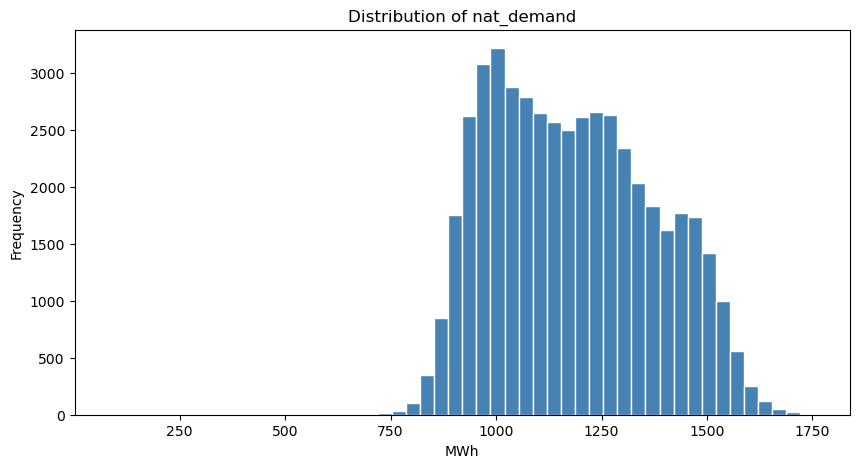

In [9]:
#histogram

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['nat_demand'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of nat_demand')
plt.xlabel('MWh')
plt.ylabel('Frequency')
plt.show()

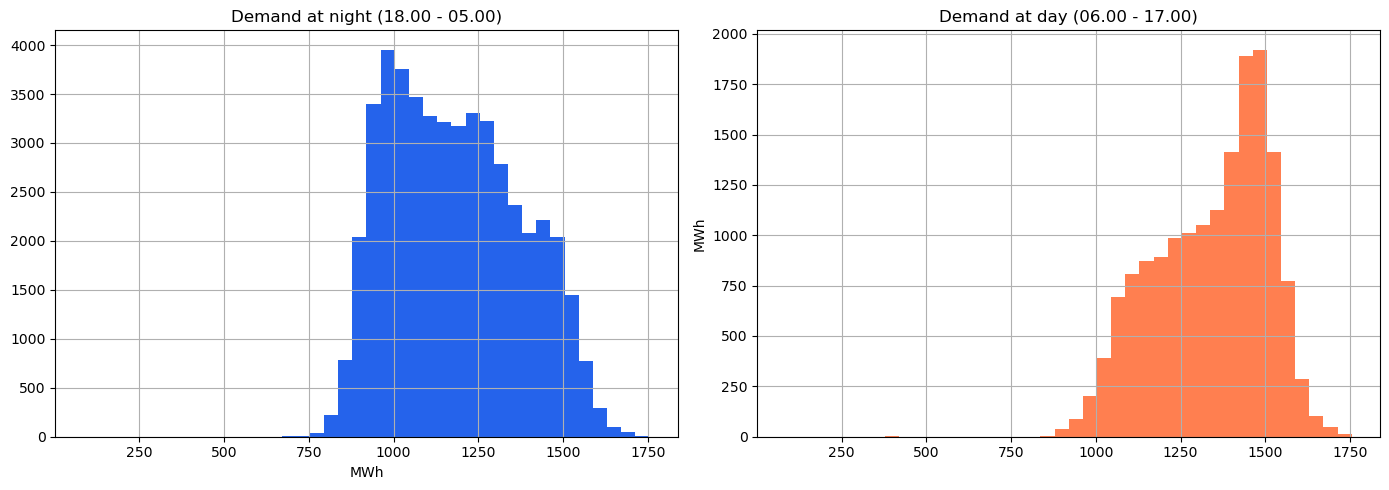

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_time[df_time.index.hour.isin(list(range(0,24)) + list(range(0,6)))]['nat_demand'].hist(bins=40, ax=axes[0], color='#2563EB')
axes[0].set_title('Demand at night (18.00 - 05.00)')
axes[0].set_xlabel('MWh')

df_time[df_time.index.hour.isin(range(10, 18))]['nat_demand'].hist(bins=40, ax=axes[1], color='coral')
axes[1].set_title('Demand at day (06.00 - 17.00)')
axes[1].set_ylabel('MWh')

plt.tight_layout()
plt.show()

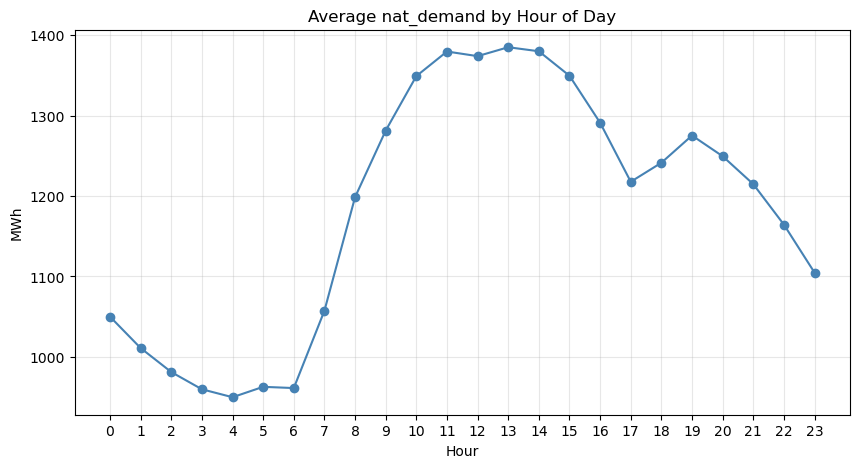

In [11]:
#trend hourly

plt.figure(figsize=(10, 5))
df_time.groupby(df_time.index.hour)['nat_demand'].mean().plot(color='steelblue', marker='o')
plt.title('Average nat_demand by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('MWh')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

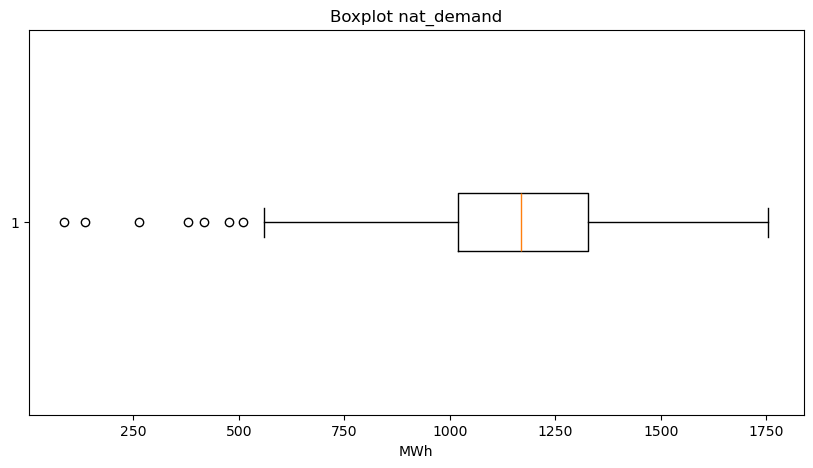

In [12]:
#boxplot

plt.figure(figsize=(10, 5))
plt.boxplot(df['nat_demand'], vert=False)
plt.title('Boxplot nat_demand')
plt.xlabel('MWh')
plt.show()

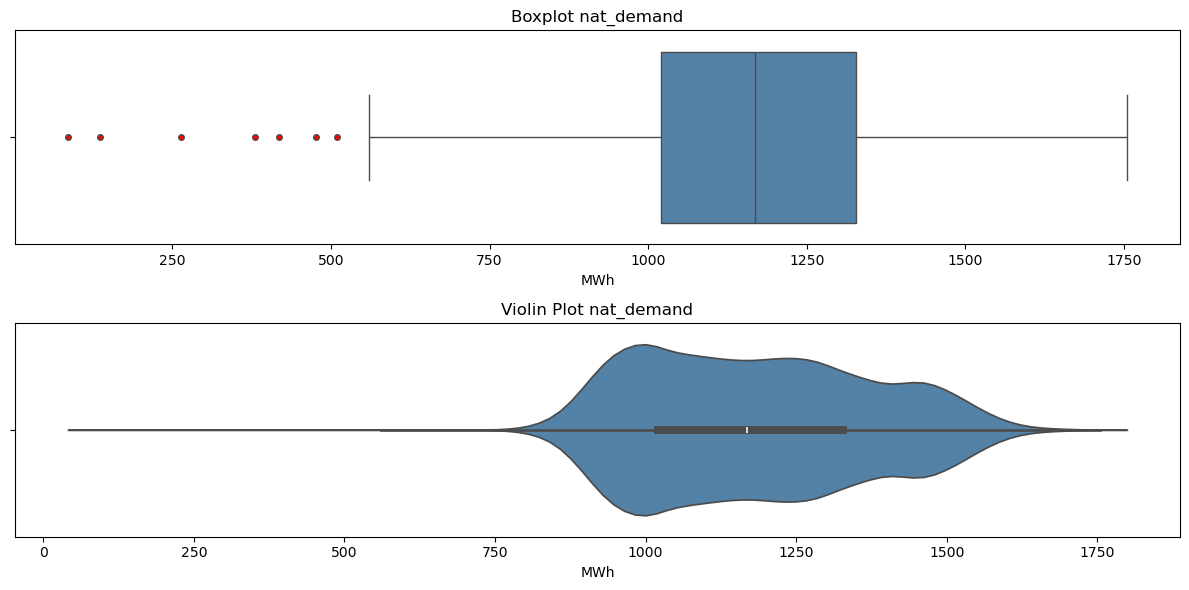

In [13]:
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Boxplot
sns.boxplot(x=df['nat_demand'], ax=axes[0], color='steelblue', flierprops=dict(marker='o', markerfacecolor='red', markersize=4))
axes[0].set_title('Boxplot nat_demand')
axes[0].set_xlabel('MWh')

# Violin plot 
sns.violinplot(x=df['nat_demand'], ax=axes[1], color='steelblue')
axes[1].set_title('Violin Plot nat_demand')
axes[1].set_xlabel('MWh')

plt.tight_layout()
plt.show()

In [14]:
#check outlier

Q1 = df['nat_demand'].quantile(0.25)
Q3 = df['nat_demand'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[df['nat_demand'] < Q1 - 1.5*IQR]
print(f"Below fence outlier: {len(outliers)}")
print(outliers[['nat_demand']].sort_values('nat_demand'))

Below fence outlier: 7
       nat_demand
35483     85.1925
35484    135.7636
35485    263.6183
21755    380.5936
35486    417.4492
35487    475.8024
520      509.8358


In [15]:
outliers_df = outliers.sort_values('nat_demand')
outliers_df

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
35483,2019-01-20 12:00:00,85.1925,29.394678,0.016237,0.033951,24.225527,29.144678,0.016504,0.202942,12.431692,29.144678,0.014662,0.050812,1.413640,0,0,0
35484,2019-01-20 13:00:00,135.7636,29.294672,0.016032,0.062653,24.641796,29.372797,0.016513,0.125244,14.316523,29.435297,0.014899,0.084290,1.615353,0,0,0
35485,2019-01-20 14:00:00,263.6183,28.969019,0.015850,0.067841,25.936263,29.547144,0.016460,0.057800,15.979043,29.187769,0.014873,0.114075,1.949015,0,0,0
21755,2017-06-27 12:00:00,380.5936,28.446252,0.017640,0.113861,5.408851,27.977502,0.019158,0.256470,5.553203,26.618127,0.017243,0.255127,3.294285,0,0,1
35486,2019-01-20 15:00:00,417.4492,28.403619,0.015743,0.046555,27.945601,29.544244,0.016437,0.035233,16.643166,28.419244,0.014809,0.118805,2.599067,0,0,0
35487,2019-01-20 16:00:00,475.8024,27.655542,0.015736,0.025024,29.566897,28.780542,0.016301,0.044052,15.792458,27.405542,0.014706,0.113037,3.379718,0,0,0
520,2015-01-24 17:00:00,509.8358,27.034692,0.016271,0.194885,22.125257,28.706567,0.016065,0.099915,7.182586,25.456567,0.015714,0.086212,0.728335,0,0,0


In [16]:
#drop outlier

outlier_timestamps = df_time.iloc[[35483, 35484, 35485, 21755, 35486, 35487, 520]].index

# df_clean = df.drop(outliers_df.index)
df_clean = df_time.drop(outlier_timestamps)
print(f"Rows before: {len(df_time)}, Rows after: {len(df_clean)}")

Rows before: 48048, Rows after: 48041


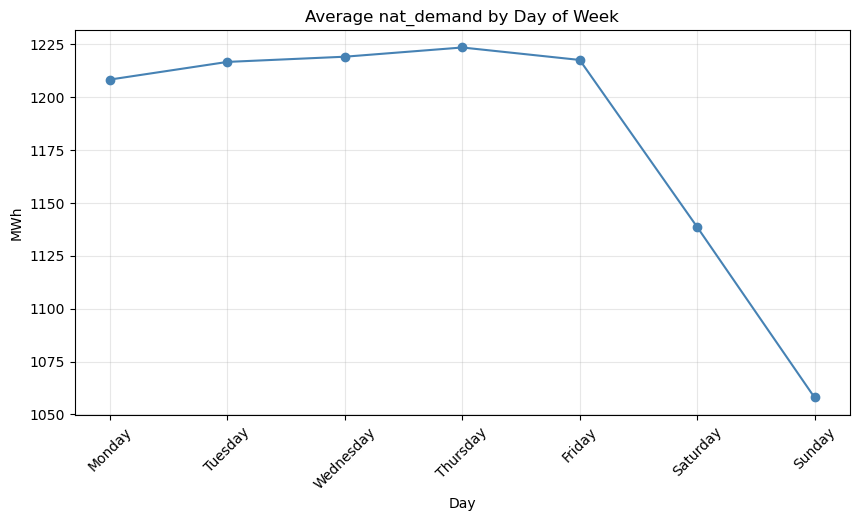

In [17]:
#day-of-week pattern

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
df_clean.groupby(df_clean.index.dayofweek)['nat_demand'].mean().plot(color='steelblue', marker='o')
plt.title('Average nat_demand by Day of Week')
plt.xlabel('Day')
plt.ylabel('MWh')
plt.xticks(range(7), days, rotation=45)
plt.grid(alpha=0.3)
plt.show()

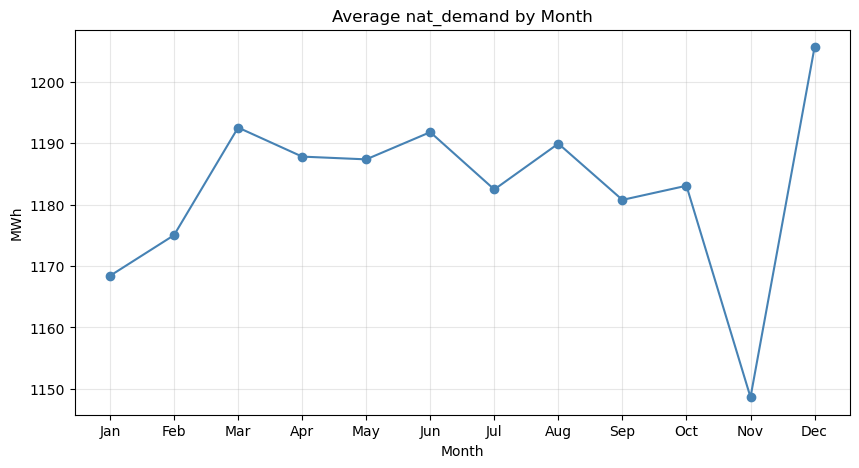

In [18]:
#monthly pattern

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10, 5))
df_clean.groupby(df_clean.index.month)['nat_demand'].mean().plot(color='steelblue', marker='o')
plt.title('Average nat_demand by Month')
plt.xlabel('Month')
plt.ylabel('MWh')
plt.xticks(range(1, 13), months)
plt.grid(alpha=0.3)
plt.show()

<Figure size 1600x500 with 0 Axes>

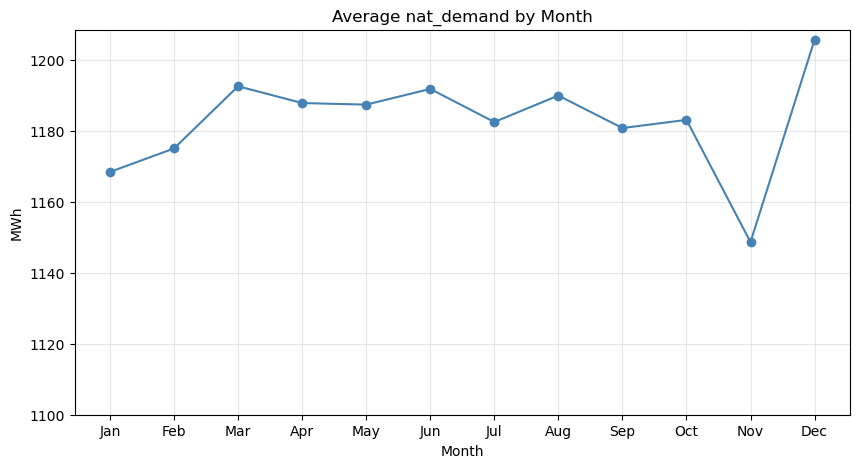

In [19]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig= plt.figure(figsize=(16, 5))

# settig ylim
plt.figure(figsize=(10, 5))
df_clean.groupby(df_clean.index.month)['nat_demand'].mean().plot(color='steelblue', marker='o')
plt.title('Average nat_demand by Month')
plt.xlabel('Month')
plt.ylabel('MWh')
plt.xticks(range(1, 13), months)
plt.ylim(1100)
plt.grid(alpha=0.3)
plt.show()

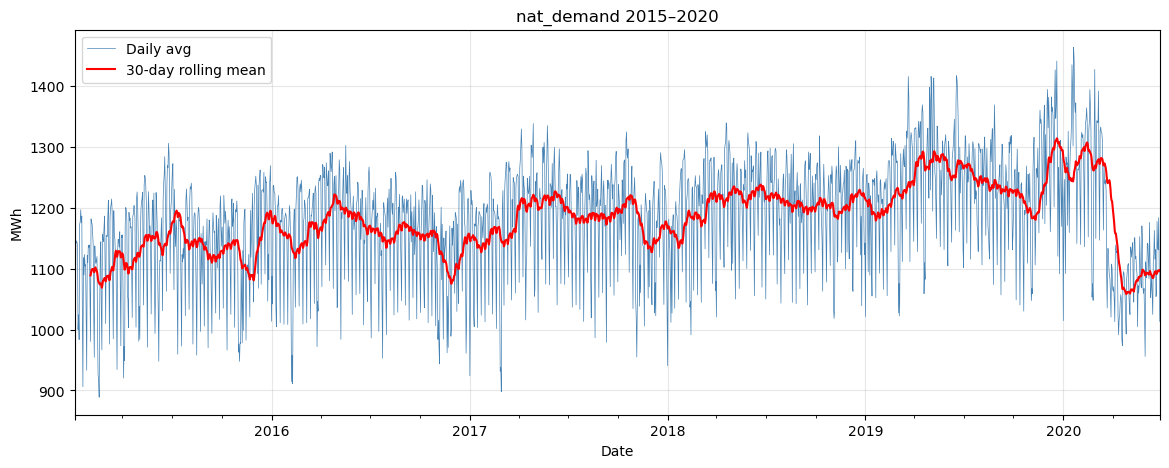

In [20]:
#full time series plot

plt.figure(figsize=(14, 5))
df_clean['nat_demand'].resample('D').mean().plot(color='steelblue', linewidth=0.5, label='Daily avg')
df_clean['nat_demand'].resample('D').mean().rolling(30).mean().plot(color='red', linewidth=1.5, label='30-day rolling mean')
plt.title('nat_demand 2015–2020')
plt.xlabel('Date')
plt.ylabel('MWh')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

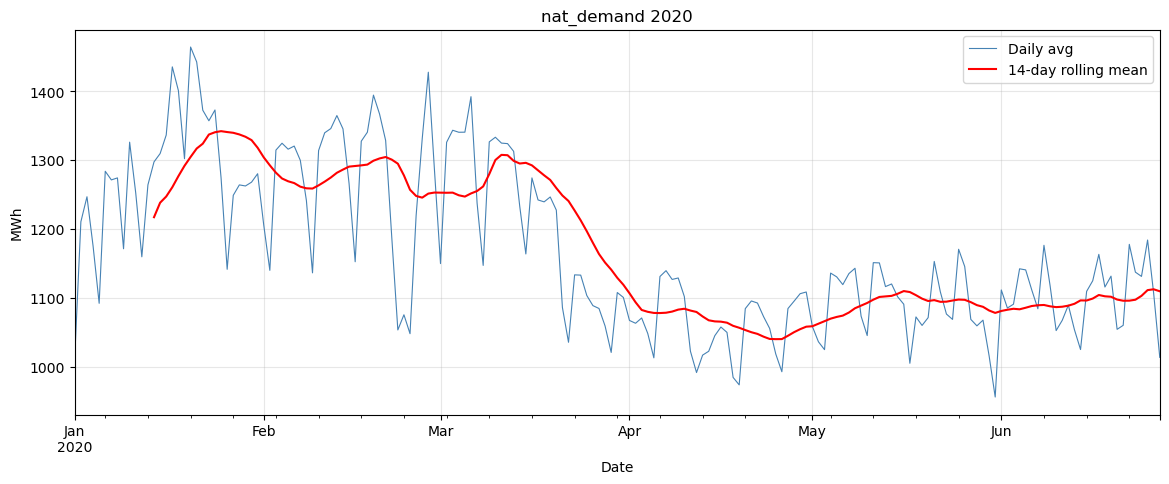

In [21]:
# Zoom ke 2020
plt.figure(figsize=(14, 5))
df_2020 = df_clean.loc['2020-01-01':'2020-12-31']
df_2020['nat_demand'].resample('D').mean().plot(color='steelblue', linewidth=0.8, label='Daily avg')
df_2020['nat_demand'].resample('D').mean().rolling(14).mean().plot(color='red', linewidth=1.5, label='14-day rolling mean')
plt.title('nat_demand 2020')
plt.xlabel('Date')
plt.ylabel('MWh')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

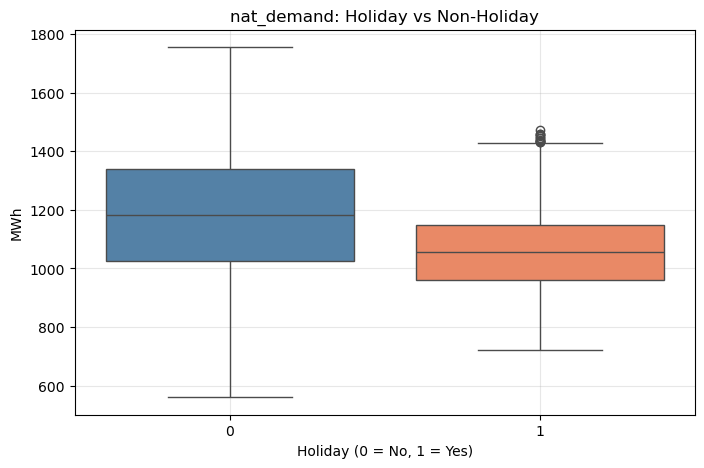

In [22]:
#holiday effect


plt.figure(figsize=(8, 5))
sns.boxplot(x='holiday', y='nat_demand', data=df_clean.reset_index(),
            hue='holiday', palette=['steelblue', 'coral'], legend=False)
plt.title('nat_demand: Holiday vs Non-Holiday')
plt.xlabel('Holiday (0 = No, 1 = Yes)')
plt.ylabel('MWh')
plt.grid(alpha=0.3)
plt.show()

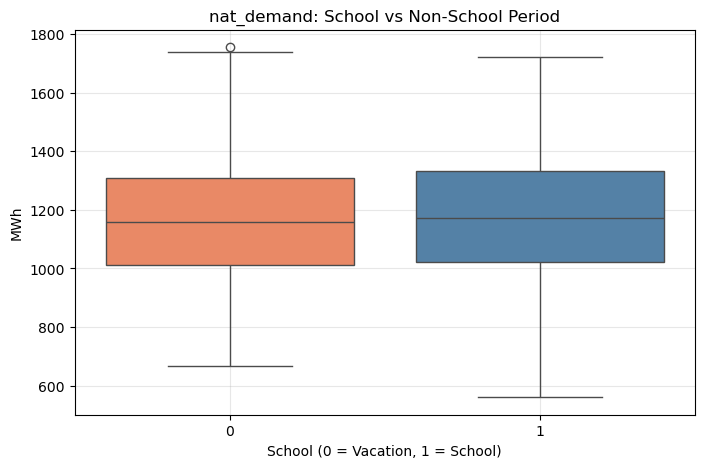

In [23]:
#school period effect

plt.figure(figsize=(8, 5))
sns.boxplot(x='school', y='nat_demand', data=df_clean.reset_index(),
            hue='school', palette=['coral', 'steelblue'], legend=False)
plt.title('nat_demand: School vs Non-School Period')
plt.xlabel('School (0 = Vacation, 1 = School)')
plt.ylabel('MWh')
plt.grid(alpha=0.3)
plt.show()

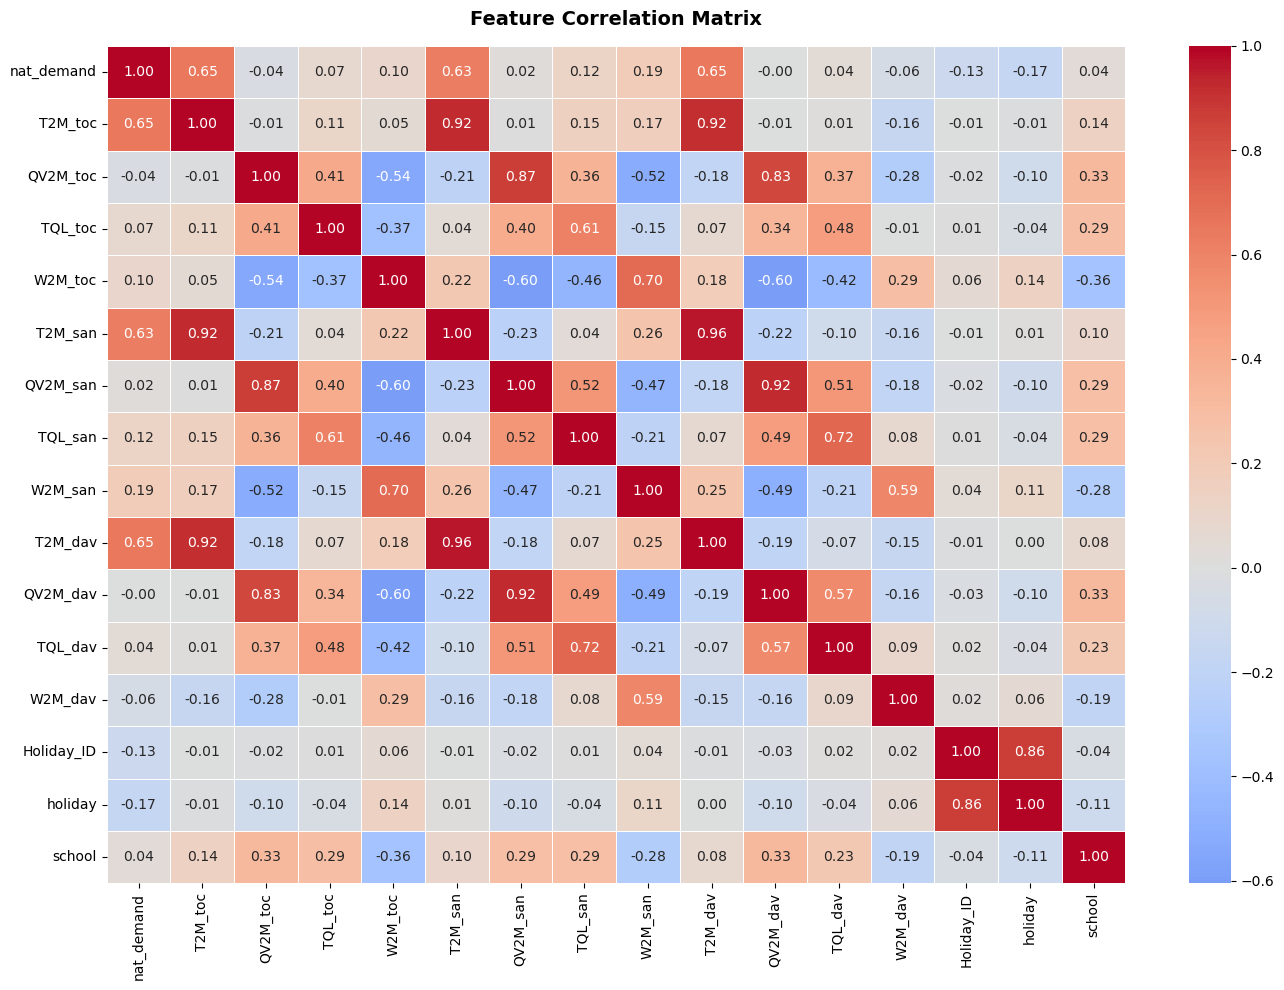

In [24]:
#correlation

plt.figure(figsize=(14, 10))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Feature Engineering

In [25]:
# Extract temporal features
import numpy as np

df_fe = df_clean.copy()

# Temporal features
df_fe['hour'] = df_fe.index.hour
df_fe['dayofweek'] = df_fe.index.dayofweek
df_fe['month'] = df_fe.index.month
df_fe['year'] = df_fe.index.year
df_fe['dayofyear'] = df_fe.index.dayofyear
df_fe['quarter'] = df_fe.index.quarter
df_fe['is_weekend'] = (df_fe.index.dayofweek >= 5).astype(int)
df_fe['is_business_hour'] = ((df_fe.index.hour >= 9) & (df_fe.index.hour <= 17) & (df_fe.index.dayofweek < 5)).astype(int)

# Cyclical encoding
df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['hour'] / 24)
df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['hour'] / 24)
df_fe['dow_sin'] = np.sin(2 * np.pi * df_fe['dayofweek'] / 7)
df_fe['dow_cos'] = np.cos(2 * np.pi * df_fe['dayofweek'] / 7)
df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)

# Lag features
for lag in [1, 2, 3, 4, 6, 12, 24, 48, 168]:
    df_fe[f'lag_{lag}'] = df_fe['nat_demand'].shift(lag)

# Rolling statistics - multiple windows
for window in [6, 12, 24, 168]:
    df_fe[f'rolling_mean_{window}'] = df_fe['nat_demand'].shift(1).rolling(window=window).mean()
    df_fe[f'rolling_std_{window}'] = df_fe['nat_demand'].shift(1).rolling(window=window).std()

# Differencing
df_fe['diff_1h'] = df_fe['nat_demand'].diff(1)
df_fe['diff_24h'] = df_fe['nat_demand'].diff(24)

# Drop NaN
df_fe = df_fe.dropna()
print(df_fe.shape)

# Target variables
for h in [1, 6, 12, 24]:
    df_fe[f'target_{h}h'] = df_fe['nat_demand'].shift(-h)

df_fe = df_fe.dropna()
print(df_fe.shape)
print(df_fe[['nat_demand', 'target_1h', 'target_6h', 'target_12h', 'target_24h']].head(10))

(47873, 49)
(47849, 53)
                     nat_demand  target_1h  target_6h  target_12h  target_24h
datetime                                                                     
2015-01-10 01:00:00    906.9580   863.5135   897.8229   1161.4116    924.2795
2015-01-10 02:00:00    863.5135   848.4447  1021.6720   1133.3133    887.4576
2015-01-10 03:00:00    848.4447   839.8821  1108.9439   1100.6097    858.9606
2015-01-10 04:00:00    839.8821   847.1073  1165.4756   1082.6875    847.4881
2015-01-10 05:00:00    847.1073   848.4718  1179.0630   1051.4135    842.7522
2015-01-10 06:00:00    848.4718   897.8229  1173.0899   1088.8689    807.4211
2015-01-10 07:00:00    897.8229  1021.6720  1161.4116   1144.2722    813.1819
2015-01-10 08:00:00   1021.6720  1108.9439  1133.3133   1102.2466    873.8010
2015-01-10 09:00:00   1108.9439  1165.4756  1100.6097   1064.1510    935.3192
2015-01-10 10:00:00   1165.4756  1179.0630  1082.6875   1030.4566   1009.0054


In [26]:
# #extract temporal features

# df_fe = df_clean.copy()

# # Temporal features
# df_fe['hour'] = df_fe.index.hour
# df_fe['dayofweek'] = df_fe.index.dayofweek
# df_fe['month'] = df_fe.index.month
# df_fe['is_weekend'] = (df_fe.index.dayofweek >= 5).astype(int)

# # Cyclical encoding
# import numpy as np
# df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['hour'] / 24)
# df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['hour'] / 24)
# df_fe['dow_sin'] = np.sin(2 * np.pi * df_fe['dayofweek'] / 7)
# df_fe['dow_cos'] = np.cos(2 * np.pi * df_fe['dayofweek'] / 7)
# df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
# df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)

# print(df_fe.shape)
# df_fe.head()

In [27]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 47849 entries, 2015-01-10 01:00:00 to 2020-06-26 00:00:00
Data columns (total 53 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   nat_demand        47849 non-null  float64
 1   T2M_toc           47849 non-null  float64
 2   QV2M_toc          47849 non-null  float64
 3   TQL_toc           47849 non-null  float64
 4   W2M_toc           47849 non-null  float64
 5   T2M_san           47849 non-null  float64
 6   QV2M_san          47849 non-null  float64
 7   TQL_san           47849 non-null  float64
 8   W2M_san           47849 non-null  float64
 9   T2M_dav           47849 non-null  float64
 10  QV2M_dav          47849 non-null  float64
 11  TQL_dav           47849 non-null  float64
 12  W2M_dav           47849 non-null  float64
 13  Holiday_ID        47849 non-null  int64  
 14  holiday           47849 non-null  int64  
 15  school            47849 non-null  int64  
 16  hour 

In [28]:
# #lag features

# for lag in [72, 96, 120, 144, 168]:
#     df_fe[f'lag_{lag}'] = df_fe['nat_demand'].shift(lag)

# # Rolling statistics (window dari lag-72 ke belakang)
# df_fe['rolling_mean_72'] = df_fe['nat_demand'].shift(72).rolling(window=24).mean()
# df_fe['rolling_std_72'] = df_fe['nat_demand'].shift(72).rolling(window=24).std()

# # Drop NaN yang muncul akibat lag
# df_fe = df_fe.dropna()

# print(df_fe.shape)

In [29]:
# # Create target variables for 12h and 24h forecast horizons
# for h in [12, 24]:
#     df_fe[f'target_{h}h'] = df_fe['nat_demand'].shift(-h)

# # Drop NaN rows created by negative shift
# df_fe = df_fe.dropna()

# print(df_fe.shape)
# print(df_fe[['nat_demand', 'target_12h', 'target_24h']].head(30))

# Create target variables for 1h, 6h, 12h, 24h forecast horizons
# for h in [1, 6, 12, 24]:
#     df_fe[f'target_{h}h'] = df_fe['nat_demand'].shift(-h)

# # Drop NaN rows created by negative shiyaift
# df_fe = df_fe.dropna()

# print(df_fe.shape)
# print(df_fe[['nat_demand', 'target_1h', 'target_6h', 'target_12h', 'target_24h']].head(10))

In [30]:
pd.set_option('display.max_columns', None)
df_fe

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school,hour,dayofweek,month,year,dayofyear,quarter,is_weekend,is_business_hour,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_2,lag_3,lag_4,lag_6,lag_12,lag_24,lag_48,lag_168,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,rolling_mean_24,rolling_std_24,rolling_mean_168,rolling_std_168,diff_1h,diff_24h,target_1h,target_6h,target_12h,target_24h
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-10 01:00:00,906.9580,24.976495,0.017215,0.025253,21.335333,23.554620,0.016421,0.051376,12.485627,22.288995,0.015735,0.121826,6.229961,0,0,0,1,5,1,2015,10,1,1,0,0.258819,0.965926,-0.974928,-0.222521,5.000000e-01,0.866025,949.5031,989.8507,1033.8639,1061.3146,1105.8630,1073.4350,943.6081,962.4068,970.3450,1037.696817,59.327958,1042.719867,45.224532,999.013846,78.862833,1092.047710,167.093865,-42.5451,-36.6501,863.5135,897.8229,1161.4116,924.2795
2015-01-10 02:00:00,863.5135,24.906274,0.017337,0.034378,22.177057,23.429712,0.016337,0.038712,12.949576,22.296899,0.015712,0.117706,6.395434,0,0,0,2,5,1,2015,10,1,1,0,0.500000,0.866025,-0.974928,-0.222521,5.000000e-01,0.866025,906.9580,949.5031,989.8507,1033.8639,1085.7856,1075.0293,917.0640,928.1036,912.1755,1004.545983,68.485292,1028.846783,58.524398,997.486758,80.323661,1091.670407,167.441523,-43.4445,-53.5505,848.4447,1021.6720,1133.3133,887.4576
2015-01-10 03:00:00,848.4447,24.879724,0.017512,0.045349,22.742188,23.309412,0.016292,0.028526,13.091533,22.325037,0.015704,0.123718,6.426799,0,0,0,3,5,1,2015,10,1,1,0,0.707107,0.707107,-0.974928,-0.222521,5.000000e-01,0.866025,863.5135,906.9580,949.5031,989.8507,1061.3146,1059.6223,895.9092,917.9997,900.2688,967.500633,75.508032,1011.220467,73.330003,995.255488,83.341887,1091.380752,167.795604,-15.0688,-47.4645,839.8821,1108.9439,1100.6097,858.9606
2015-01-10 04:00:00,839.8821,24.907922,0.017673,0.047501,22.630025,23.306360,0.016337,0.016182,13.050650,22.368860,0.015704,0.123779,6.351922,0,0,0,4,5,1,2015,10,1,1,0,0.866025,0.500000,-0.974928,-0.222521,5.000000e-01,0.866025,848.4447,863.5135,906.9580,949.5031,1033.8639,1026.1627,885.2720,910.9537,889.9538,932.022317,72.564873,993.622333,85.059906,993.277800,86.312089,1091.072275,168.196208,-8.5626,-45.3899,847.1073,1165.4756,1082.6875,847.4881
2015-01-10 05:00:00,847.1073,24.932520,0.017795,0.036087,21.731658,23.354395,0.016422,0.009590,12.846088,22.424707,0.015735,0.118378,6.165582,0,0,0,5,5,1,2015,10,1,1,0,0.965926,0.258819,-0.974928,-0.222521,5.000000e-01,0.866025,839.8821,848.4447,863.5135,906.9580,989.8507,997.3978,884.8111,928.7240,893.6865,899.692017,60.290837,978.098950,94.998824,991.386554,89.229555,1090.774229,168.598609,7.2252,-37.7038,848.4718,1179.0630,1051.4135,842.7522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-25 20:00:00,1279.2819,27.305139,0.020456,0.024117,13.207736,26.148889,0.019700,0.081024,2.191878,24.008264,0.018556,0.199280,2.177908,0,0,1,20,3,6,2020,177,2,0,0,-0.866025,0.500000,0.433884,-0.900969,1.224647e-16,-1.000000,1276.8695,1169.9334,1142.2448,1217.9484,1343.3510,1193.0333,1233.2471,1125.1268,1184.3943,1241.426350,77.934310,1271.735317,76.092231,1176.914487,128.296254,1123.337827,125.745244,2.4124,46.0348,1260.8193,1040.0120,1145.1510,1128.5592
2020-06-25 21:00:00,1260.8193,27.156305,0.020402,0.027321,13.583287,25.796930,0.019525,0.069763,2.614863,23.718805,0.018434,0.187439,2.247069,0,0,1,21,3,6,2020,177,2,0,0,-0.707107,0.707107,0.433884,-0.900969,1.224647e-16,-1.000000,1279.2819,1276.8695,1169.9334,1142.2448,1298.2110,1256.3163,1221.2048,1114.4679,1184.9695,1230.748167,64.387965,1278.922700,71.942746,1178.832604,129.513435,1123.902634,126.233288,-18.4626,39.6145,1226.9634,1016.4073,1173.6152,1112.7488
2020-06-25 22:00

## Normalization

In [31]:
# splits_expanding CV 4

splits_expanding = [
    ('2015-01', '2015-12', '2016-01', '2016-12'),
    ('2015-01', '2016-12', '2017-01', '2017-12'),
    ('2015-01', '2017-12', '2018-01', '2018-12'),
    ('2015-01', '2018-12', '2019-01', '2019-12')
]

print("Splits updated!")

Splits updated!


In [32]:
from sklearn.preprocessing import MinMaxScaler

feature_cols = [col for col in df_fe.columns if col not in ['target_1h', 
                                                            'target_6h', 
                                                            'target_12h', 
                                                            'target_24h',
                                                            'Holiday_ID',
                                                            'hour',
                                                            'dayofweek',
                                                            'month']]

def prepare_fold(df, train_start, train_end, val_start, val_end, target_col):
    train = df.loc[train_start:train_end]
    val = df.loc[val_start:val_end]
    
    # Normalize per fold (no leakage)
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    X_train = scaler_X.fit_transform(train[feature_cols])
    X_val = scaler_X.transform(val[feature_cols])
    
    y_train = scaler_y.fit_transform(train[[target_col]])
    y_val = scaler_y.transform(val[[target_col]])
    
    return X_train, X_val, y_train, y_val, scaler_y

print("prepare_fold function defined!")

prepare_fold function defined!


In [33]:
print(feature_cols)
print(len(feature_cols))

['nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav', 'holiday', 'school', 'year', 'dayofyear', 'quarter', 'is_weekend', 'is_business_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_6', 'rolling_std_6', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168', 'rolling_std_168', 'diff_1h', 'diff_24h']
45


In [34]:
# #GRU architecture

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout

# def build_gru_model(input_shape):
#     model = Sequential([
#         GRU(64, return_sequences=True, input_shape=input_shape),
#         Dropout(0.2),
#         GRU(32, return_sequences=False),
#         Dropout(0.2),
#         Dense(1)
#     ])
#     model.compile(optimizer='adam', loss='mse', metrics=['mae'])
#     return model

# print("GRU model function defined!")


# from tensorflow.keras.layers import Input

# def build_gru_model(input_shape):
#     inputs = Input(shape=input_shape)
#     x = GRU(64, return_sequences=True)(inputs)
#     x = Dropout(0.2)(x)
#     x = GRU(32, return_sequences=False)(x)
#     x = Dropout(0.2)(x)
#     outputs = Dense(1)(x)
    
#     model = tf.keras.Model(inputs, outputs)
#     model.compile(optimizer='adam', loss='mse', metrics=['mae'])
#     return model

def build_gru_model(input_shape, n_layers=2):
    inputs = Input(shape=input_shape)
    
    if n_layers == 3:  # 3 layer total
        x = GRU(64, return_sequences=False)(inputs)
        x = Dropout(0.2)(x)
    elif n_layers == 5:  # 5 layer total
        x = GRU(64, return_sequences=True)(inputs)
        x = Dropout(0.2)(x)
        x = GRU(32, return_sequences=False)(x)
        x = Dropout(0.2)(x)
    elif n_layers == 7:  # 7 layer total
        x = GRU(128, return_sequences=True)(inputs)
        x = Dropout(0.2)(x)
        x = GRU(64, return_sequences=True)(x)
        x = Dropout(0.2)(x)
        x = GRU(32, return_sequences=False)(x)
        x = Dropout(0.2)(x)
    
    outputs = Dense(1)(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

print("build_gru_model updated!")

build_gru_model updated!


In [35]:
#reshape input to 3D

def reshape_for_gru(X):
    # GRU expects (samples, timesteps, features)
    # Kita treat setiap row sebagai 1 timestep
    return X.reshape((X.shape[0], 1, X.shape[1]))

print("reshape function defined!")

reshape function defined!


In [36]:
# #12hr horizon

# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np

# def run_cv(splits, target_col, cv_name):
#     results = []
    
#     for i, (train_start, train_end, val_start, val_end) in enumerate(splits):
#         print(f"\n{cv_name} - Fold {i+1}: Train {train_start}–{train_end} | Val {val_start}–{val_end}")
        
#         # Prepare data
#         X_train, X_val, y_train, y_val, scaler_y = prepare_fold(
#             df_fe, train_start, train_end, val_start, val_end, target_col)
        
#         # Reshape for GRU
#         X_train_3d = reshape_for_gru(X_train)
#         X_val_3d = reshape_for_gru(X_val)
        
#         # Build & train model
#         model = build_gru_model((X_train_3d.shape[1], X_train_3d.shape[2]))
#         model.fit(X_train_3d, y_train, epochs=20, batch_size=64, verbose=0)
        
#         # Predict & inverse transform
#         y_pred_scaled = model.predict(X_val_3d, verbose=0)
#         y_pred = scaler_y.inverse_transform(y_pred_scaled)
#         y_true = scaler_y.inverse_transform(y_val)
        
#         # Metrics
#         mae = mean_absolute_error(y_true, y_pred)
#         rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#         mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        
#         results.append({'fold': i+1, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape})
#         print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")
    
#     return pd.DataFrame(results)

# print("run_cv function defined!")

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def run_cv(splits, target_col, cv_name, n_layers=3):
    results = []
    
    for i, (train_start, train_end, val_start, val_end) in enumerate(splits):
        print(f"\n{cv_name} | layers={n_layers} - Fold {i+1}: Train {train_start}–{train_end} | Val {val_start}–{val_end}")
        
        X_train, X_val, y_train, y_val, scaler_y = prepare_fold(
            df_fe, train_start, train_end, val_start, val_end, target_col)
        
        X_train_3d = reshape_for_gru(X_train)
        X_val_3d = reshape_for_gru(X_val)
        
        model = build_gru_model((X_train_3d.shape[1], X_train_3d.shape[2]), n_layers=n_layers)
        model.fit(X_train_3d, y_train,
                  epochs=50,
                  batch_size=64,
                  validation_data=(X_val_3d, y_val),
                  callbacks=callbacks,
                  verbose=0)
        
        y_pred_scaled = model.predict(X_val_3d, verbose=0)
        y_pred = scaler_y.inverse_transform(y_pred_scaled)
        y_true = scaler_y.inverse_transform(y_val)
        
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        
        results.append({'fold': i+1, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape})
        print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")
    
    return pd.DataFrame(results)

print("run_cv updated!")

run_cv updated!


In [38]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

print("Callbacks defined!")

Callbacks defined!


In [39]:
# Run CV untuk 3 arsitektur
results_3layer = run_cv(splits_expanding, 'target_1h', 'GRU-3layer', n_layers=3)
results_5layer = run_cv(splits_expanding, 'target_1h', 'GRU-5layer', n_layers=5)
results_7layer = run_cv(splits_expanding, 'target_1h', 'GRU-7layer', n_layers=7)


GRU-3layer | layers=3 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–2016-12
MAE: 24.46 | RMSE: 31.91 | MAPE: 2.16%

GRU-3layer | layers=3 - Fold 2: Train 2015-01–2016-12 | Val 2017-01–2017-12
MAE: 42.77 | RMSE: 54.21 | MAPE: 3.58%

GRU-3layer | layers=3 - Fold 3: Train 2015-01–2017-12 | Val 2018-01–2018-12
MAE: 22.84 | RMSE: 30.05 | MAPE: 1.91%

GRU-3layer | layers=3 - Fold 4: Train 2015-01–2018-12 | Val 2019-01–2019-12
MAE: 41.56 | RMSE: 52.39 | MAPE: 3.43%

GRU-5layer | layers=5 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–2016-12
MAE: 55.97 | RMSE: 68.14 | MAPE: 4.87%

GRU-5layer | layers=5 - Fold 2: Train 2015-01–2016-12 | Val 2017-01–2017-12
MAE: 45.26 | RMSE: 57.12 | MAPE: 3.82%

GRU-5layer | layers=5 - Fold 3: Train 2015-01–2017-12 | Val 2018-01–2018-12
MAE: 41.87 | RMSE: 51.76 | MAPE: 3.55%

GRU-5layer | layers=5 - Fold 4: Train 2015-01–2018-12 | Val 2019-01–2019-12
MAE: 39.37 | RMSE: 49.30 | MAPE: 3.21%

GRU-7layer | layers=7 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–201

In [40]:
results_3layer['architecture'] = 'GRU-3layer'
results_5layer['architecture'] = 'GRU-5layer'
results_7layer['architecture'] = 'GRU-7layer'

all_arch = pd.concat([results_3layer, results_5layer, results_7layer])
summary_arch = all_arch.groupby('architecture')[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print(summary_arch)

                MAE   RMSE  MAPE
architecture                    
GRU-3layer    32.91  42.14  2.77
GRU-5layer    45.62  56.58  3.86
GRU-7layer    44.27  55.77  3.69


In [41]:
results_3layer_6h = run_cv(splits_expanding, 'target_6h', 'GRU-3layer', n_layers=3)
results_5layer_6h = run_cv(splits_expanding, 'target_6h', 'GRU-5layer', n_layers=5)
results_7layer_6h = run_cv(splits_expanding, 'target_6h', 'GRU-7layer', n_layers=7)


GRU-3layer | layers=3 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–2016-12
MAE: 94.70 | RMSE: 119.12 | MAPE: 7.88%

GRU-3layer | layers=3 - Fold 2: Train 2015-01–2016-12 | Val 2017-01–2017-12
MAE: 66.20 | RMSE: 84.24 | MAPE: 5.66%

GRU-3layer | layers=3 - Fold 3: Train 2015-01–2017-12 | Val 2018-01–2018-12
MAE: 61.25 | RMSE: 74.90 | MAPE: 5.19%

GRU-3layer | layers=3 - Fold 4: Train 2015-01–2018-12 | Val 2019-01–2019-12
MAE: 65.04 | RMSE: 80.44 | MAPE: 5.26%

GRU-5layer | layers=5 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–2016-12
MAE: 93.10 | RMSE: 114.06 | MAPE: 7.84%

GRU-5layer | layers=5 - Fold 2: Train 2015-01–2016-12 | Val 2017-01–2017-12
MAE: 61.73 | RMSE: 79.90 | MAPE: 5.46%

GRU-5layer | layers=5 - Fold 3: Train 2015-01–2017-12 | Val 2018-01–2018-12
MAE: 59.61 | RMSE: 73.53 | MAPE: 4.97%

GRU-5layer | layers=5 - Fold 4: Train 2015-01–2018-12 | Val 2019-01–2019-12
MAE: 61.20 | RMSE: 76.83 | MAPE: 4.96%

GRU-7layer | layers=7 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–2

In [42]:
results_3layer_6h['architecture'] = 'GRU-3layer'
results_5layer_6h['architecture'] = 'GRU-5layer'
results_7layer_6h['architecture'] = 'GRU-7layer'

all_arch_6h = pd.concat([results_3layer_6h, results_5layer_6h, results_7layer_6h])
summary_arch_6h = all_arch_6h.groupby('architecture')[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print("Horizon 6h:")
print(summary_arch_6h)

Horizon 6h:
                MAE   RMSE  MAPE
architecture                    
GRU-3layer    71.80  89.67  6.00
GRU-5layer    68.91  86.08  5.81
GRU-7layer    63.47  79.30  5.36


In [43]:
# Run CV untuk 3 arsitektur
results_3layer_12h = run_cv(splits_expanding, 'target_12h', 'GRU-3layer', n_layers=3)
results_5layer_12h = run_cv(splits_expanding, 'target_12h', 'GRU-5layer', n_layers=5)
results_7layer_12h = run_cv(splits_expanding, 'target_12h', 'GRU-7layer', n_layers=7)


GRU-3layer | layers=3 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–2016-12
MAE: 82.45 | RMSE: 104.39 | MAPE: 7.55%

GRU-3layer | layers=3 - Fold 2: Train 2015-01–2016-12 | Val 2017-01–2017-12
MAE: 64.95 | RMSE: 85.71 | MAPE: 5.51%

GRU-3layer | layers=3 - Fold 3: Train 2015-01–2017-12 | Val 2018-01–2018-12
MAE: 58.89 | RMSE: 79.61 | MAPE: 4.94%

GRU-3layer | layers=3 - Fold 4: Train 2015-01–2018-12 | Val 2019-01–2019-12
MAE: 64.63 | RMSE: 85.24 | MAPE: 5.24%

GRU-5layer | layers=5 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–2016-12
MAE: 81.65 | RMSE: 103.11 | MAPE: 6.88%

GRU-5layer | layers=5 - Fold 2: Train 2015-01–2016-12 | Val 2017-01–2017-12
MAE: 65.93 | RMSE: 87.24 | MAPE: 5.72%

GRU-5layer | layers=5 - Fold 3: Train 2015-01–2017-12 | Val 2018-01–2018-12
MAE: 61.93 | RMSE: 81.13 | MAPE: 5.13%

GRU-5layer | layers=5 - Fold 4: Train 2015-01–2018-12 | Val 2019-01–2019-12
MAE: 73.25 | RMSE: 93.37 | MAPE: 5.82%

GRU-7layer | layers=7 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–2

In [44]:
results_3layer_12h['architecture'] = 'GRU-3layer'
results_5layer_12h['architecture'] = 'GRU-5layer'
results_7layer_12h['architecture'] = 'GRU-7layer'

all_arch_12h = pd.concat([results_3layer_12h, results_5layer_12h, results_7layer_12h])
summary_arch_12h = all_arch_12h.groupby('architecture')[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print("Horizon 12h:")
print(summary_arch_12h)

Horizon 12h:
                MAE   RMSE  MAPE
architecture                    
GRU-3layer    67.73  88.74  5.81
GRU-5layer    70.69  91.21  5.89
GRU-7layer    67.22  89.02  5.65


In [45]:
# Run CV untuk 3 arsitektur
results_3layer_24h = run_cv(splits_expanding, 'target_24h', 'GRU-3layer', n_layers=3)
results_5layer_24h = run_cv(splits_expanding, 'target_24h', 'GRU-5layer', n_layers=5)
results_7layer_24h = run_cv(splits_expanding, 'target_24h', 'GRU-7layer', n_layers=7)


GRU-3layer | layers=3 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–2016-12
MAE: 138.96 | RMSE: 161.17 | MAPE: 11.66%

GRU-3layer | layers=3 - Fold 2: Train 2015-01–2016-12 | Val 2017-01–2017-12
MAE: 69.49 | RMSE: 91.43 | MAPE: 5.83%

GRU-3layer | layers=3 - Fold 3: Train 2015-01–2017-12 | Val 2018-01–2018-12
MAE: 63.75 | RMSE: 84.83 | MAPE: 5.41%

GRU-3layer | layers=3 - Fold 4: Train 2015-01–2018-12 | Val 2019-01–2019-12
MAE: 66.58 | RMSE: 87.17 | MAPE: 5.36%

GRU-5layer | layers=5 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–2016-12
MAE: 77.54 | RMSE: 99.72 | MAPE: 6.52%

GRU-5layer | layers=5 - Fold 2: Train 2015-01–2016-12 | Val 2017-01–2017-12
MAE: 70.68 | RMSE: 93.13 | MAPE: 6.24%

GRU-5layer | layers=5 - Fold 3: Train 2015-01–2017-12 | Val 2018-01–2018-12
MAE: 62.66 | RMSE: 82.44 | MAPE: 5.27%

GRU-5layer | layers=5 - Fold 4: Train 2015-01–2018-12 | Val 2019-01–2019-12
MAE: 68.76 | RMSE: 89.64 | MAPE: 5.53%

GRU-7layer | layers=7 - Fold 1: Train 2015-01–2015-12 | Val 2016-01–

In [46]:
results_3layer_24h['architecture'] = 'GRU-3layer'
results_5layer_24h['architecture'] = 'GRU-5layer'
results_7layer_24h['architecture'] = 'GRU-7layer'

all_arch_24h = pd.concat([results_3layer_24h, results_5layer_24h, results_7layer_24h])
summary_arch_24h = all_arch_24h.groupby('architecture')[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print("Horizon 24h:")
print(summary_arch_24h)

Horizon 24h:
                MAE    RMSE  MAPE
architecture                     
GRU-3layer    84.69  106.15  7.06
GRU-5layer    69.91   91.23  5.89
GRU-7layer    68.62   89.69  5.82


In [47]:
# Train model

# Final model - horizon 1h
# Train: 2015-2019, Test: 2020-01 to 2020-03

train_final = df_fe.loc['2015-01':'2019-12']
test_final = df_fe.loc['2020-01':'2020-02']

# Normalize
scaler_X_final = MinMaxScaler()
scalers_y = {1: MinMaxScaler(), 6: MinMaxScaler(), 12: MinMaxScaler(), 24: MinMaxScaler()}

train_final_scaled = train_final.copy()
test_final_scaled = test_final.copy()

train_final_scaled[feature_cols] = scaler_X_final.fit_transform(train_final[feature_cols])
test_final_scaled[feature_cols] = scaler_X_final.transform(test_final[feature_cols])

y_train_final = {}
y_test_final = {}

for h in [1, 6, 12, 24]:
    y_train_final[h] = scalers_y[h].fit_transform(train_final[[f'target_{h}h']])
    y_test_final[h] = scalers_y[h].transform(test_final[[f'target_{h}h']])

X_train_final = reshape_for_gru(train_final_scaled[feature_cols].values)
X_test_final = reshape_for_gru(test_final_scaled[feature_cols].values)

print(f"X_train: {X_train_final.shape}")
print(f"X_test: {X_test_final.shape}")

X_train: (43600, 1, 45)
X_test: (1440, 1, 45)


## Train final model per horizon

In [51]:
# Train final model 1h 
final_model_1h = build_gru_model((X_train_final.shape[1], X_train_final.shape[2]), n_layers=3)

history_1h = final_model_1h.fit(
    X_train_final, y_train_final[1],
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step - loss: 0.0098 - mae: 0.0728 - val_loss: 0.0019 - val_mae: 0.0348 - learning_rate: 0.0010
Epoch 2/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - loss: 0.0032 - mae: 0.0442 - val_loss: 0.0013 - val_mae: 0.0283 - learning_rate: 0.0010
Epoch 3/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - loss: 0.0024 - mae: 0.0379 - val_loss: 0.0011 - val_mae: 0.0247 - learning_rate: 0.0010
Epoch 4/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - loss: 0.0020 - mae: 0.0345 - val_loss: 0.0011 - val_mae: 0.0246 - learning_rate: 5.0000e-04
Epoch 5/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step - loss: 0.0018 - mae: 0.0326 - val_loss: 0.0011 - val_mae: 0.0251 - learning_rate: 5.0000e-04


In [52]:
# Evaluate final model 1h
y_pred_1h_scaled = final_model_1h.predict(X_test_final, verbose=0)
y_pred_1h = scalers_y[1].inverse_transform(y_pred_1h_scaled).flatten()
y_true_1h = scalers_y[1].inverse_transform(y_test_final[1]).flatten()

mae_1h = mean_absolute_error(y_true_1h, y_pred_1h)
rmse_1h = np.sqrt(mean_squared_error(y_true_1h, y_pred_1h))
mape_1h = np.mean(np.abs((y_true_1h - y_pred_1h) / y_true_1h)) * 100

print("Final Model - Horizon 1h (Test set: Jan-Feb 2020):")
print(f"MAE:  {mae_1h:.2f} MWh")
print(f"RMSE: {rmse_1h:.2f} MWh")
print(f"MAPE: {mape_1h:.2f}%")

Final Model - Horizon 1h (Test set: Jan-Feb 2020):
MAE:  42.78 MWh
RMSE: 53.70 MWh
MAPE: 3.36%


In [50]:
# Train final model 6h (GRU-3layer)
final_model_6h = build_gru_model((X_train_final.shape[1], X_train_final.shape[2]), n_layers=7)

history_6h = final_model_6h.fit(
    X_train_final, y_train_final[6],
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 777us/step - loss: 0.0141 - mae: 0.0875 - val_loss: 0.0043 - val_mae: 0.0528 - learning_rate: 0.0010
Epoch 2/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - loss: 0.0052 - mae: 0.0569 - val_loss: 0.0038 - val_mae: 0.0486 - learning_rate: 0.0010
Epoch 3/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 558us/step - loss: 0.0042 - mae: 0.0507 - val_loss: 0.0033 - val_mae: 0.0457 - learning_rate: 0.0010
Epoch 4/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step - loss: 0.0036 - mae: 0.0471 - val_loss: 0.0028 - val_mae: 0.0416 - learning_rate: 5.0000e-04
Epoch 5/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step - loss: 0.0034 - mae: 0.0456 - val_loss: 0.0028 - val_mae: 0.0418 - learning_rate: 5.0000e-04


In [53]:
# Evaluate final model 6h
y_pred_6h_scaled = final_model_6h.predict(X_test_final, verbose=0)
y_pred_6h = scalers_y[6].inverse_transform(y_pred_6h_scaled).flatten()
y_true_6h = scalers_y[6].inverse_transform(y_test_final[6]).flatten()

mae_6h = mean_absolute_error(y_true_6h, y_pred_6h)
rmse_6h = np.sqrt(mean_squared_error(y_true_6h, y_pred_6h))
mape_6h = np.mean(np.abs((y_true_6h - y_pred_6h) / y_true_6h)) * 100

print("Final Model - Horizon 6h (Test set: Jan-Feb 2020):")
print(f"MAE:  {mae_6h:.2f} MWh")
print(f"RMSE: {rmse_6h:.2f} MWh")
print(f"MAPE: {mape_6h:.2f}%")

Final Model - Horizon 6h (Test set: Jan-Feb 2020):
MAE:  66.29 MWh
RMSE: 86.27 MWh
MAPE: 5.30%


In [57]:
# Train final model 12h (GRU-3layer)
final_model_12h = build_gru_model((X_train_final.shape[1], X_train_final.shape[2]), n_layers=7)

history_12h = final_model_12h.fit(
    X_train_final, y_train_final[12],
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0130 - mae: 0.0838 - val_loss: 0.0064 - val_mae: 0.0615 - learning_rate: 0.0010
Epoch 2/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0068 - mae: 0.0626 - val_loss: 0.0048 - val_mae: 0.0522 - learning_rate: 0.0010
Epoch 3/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0057 - mae: 0.0563 - val_loss: 0.0045 - val_mae: 0.0509 - learning_rate: 0.0010
Epoch 4/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0050 - mae: 0.0521 - val_loss: 0.0042 - val_mae: 0.0488 - learning_rate: 5.0000e-04
Epoch 5/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0046 - mae: 0.0501 - val_loss: 0.0040 - val_mae: 0.0474 - learning_rate: 5.0000e-04


In [58]:
# Evaluate final model 12h
y_pred_12h_scaled = final_model_12h.predict(X_test_final, verbose=0)
y_pred_12h = scalers_y[12].inverse_transform(y_pred_12h_scaled).flatten()
y_true_12h = scalers_y[12].inverse_transform(y_test_final[12]).flatten()

mae_12h = mean_absolute_error(y_true_12h, y_pred_12h)
rmse_12h = np.sqrt(mean_squared_error(y_true_12h, y_pred_12h))
mape_12h = np.mean(np.abs((y_true_12h - y_pred_12h) / y_true_12h)) * 100

print("Final Model - Horizon 12h (Test set: Jan-Feb 2020):")
print(f"MAE:  {mae_12h:.2f} MWh")
print(f"RMSE: {rmse_12h:.2f} MWh")
print(f"MAPE: {mape_12h:.2f}%")

Final Model - Horizon 12h (Test set: Jan-Feb 2020):
MAE:  70.98 MWh
RMSE: 93.74 MWh
MAPE: 5.78%


In [60]:
# Train final model 24h (GRU-3layer)
final_model_24h = build_gru_model((X_train_final.shape[1], X_train_final.shape[2]), n_layers=7)

history_24h = final_model_24h.fit(
    X_train_final, y_train_final[24],
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0135 - mae: 0.0856 - val_loss: 0.0058 - val_mae: 0.0585 - learning_rate: 0.0010
Epoch 2/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0064 - mae: 0.0606 - val_loss: 0.0044 - val_mae: 0.0498 - learning_rate: 0.0010
Epoch 3/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0049 - mae: 0.0523 - val_loss: 0.0043 - val_mae: 0.0495 - learning_rate: 0.0010
Epoch 4/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0042 - mae: 0.0482 - val_loss: 0.0041 - val_mae: 0.0482 - learning_rate: 5.0000e-04
Epoch 5/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0040 - mae: 0.0468 - val_loss: 0.0039 - val_mae: 0.0464 - learning_rate: 5.0000e-04


In [63]:
# Evaluate final model 24h
y_pred_24h_scaled = final_model_24h.predict(X_test_final, verbose=0)
y_pred_24h = scalers_y[24].inverse_transform(y_pred_24h_scaled).flatten()
y_true_24h = scalers_y[24].inverse_transform(y_test_final[24]).flatten()

mae_24h = mean_absolute_error(y_true_24h, y_pred_24h)
rmse_24h = np.sqrt(mean_squared_error(y_true_24h, y_pred_24h))
mape_24h = np.mean(np.abs((y_true_24h - y_pred_24h) / y_true_24h)) * 100

print("Final Model - Horizon 24h (Test set: Jan-Feb 2020):")
print(f"MAE:  {mae_24h:.2f} MWh")
print(f"RMSE: {rmse_24h:.2f} MWh")
print(f"MAPE: {mape_24h:.2f}%")

Final Model - Horizon 24h (Test set: Jan-Feb 2020):
MAE:  72.80 MWh
RMSE: 97.83 MWh
MAPE: 5.67%


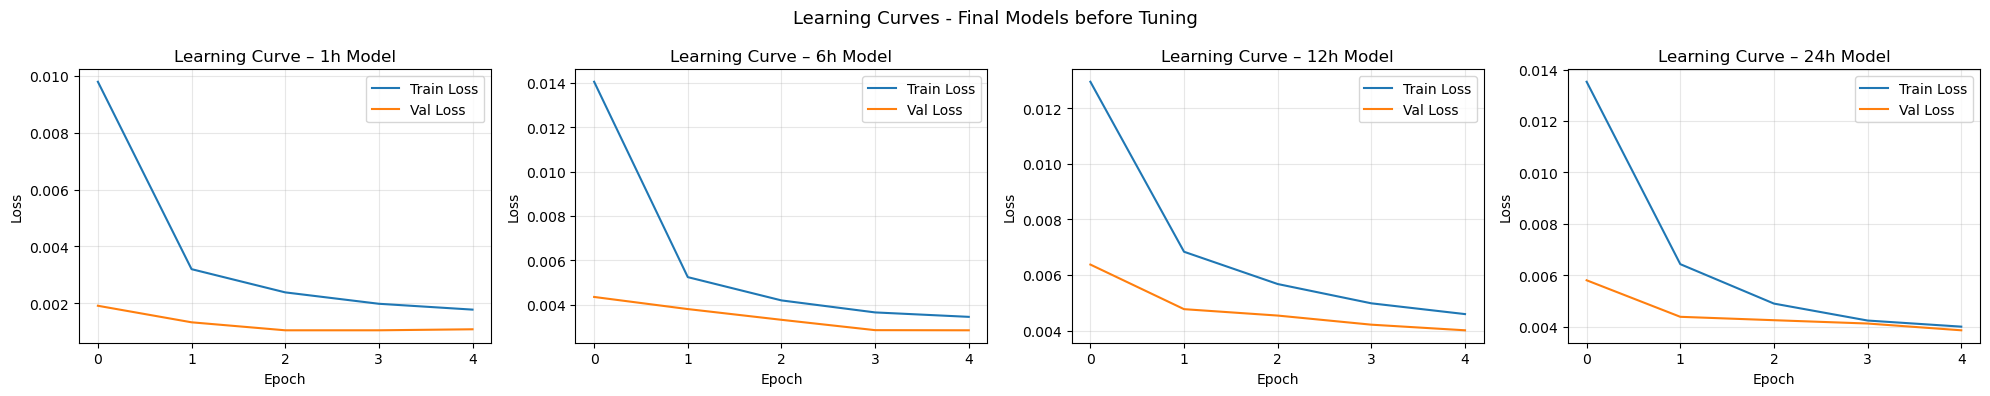

In [62]:
# Learning Curves - Final Model per Horizon
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

histories = [history_1h, history_6h, history_12h, history_24h]
horizons = ['1h', '6h', '12h', '24h']

for i, (history, horizon) in enumerate(zip(histories, horizons)):
    axes[i].plot(history.history['loss'], label='Train Loss')
    axes[i].plot(history.history['val_loss'], label='Val Loss')
    axes[i].set_title(f'Learning Curve – {horizon} Model')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle('Learning Curves - Final Models before Tuning', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
#horizon 1 hour

plt.figure(figsize=(14, 5))
plt.plot(test_final.index, y_true_1h, color='steelblue', linewidth=0.8, label='Actual')
plt.plot(test_final.index, y_pred_1h, color='red', linewidth=0.8, label='Predicted')
plt.title('Actual vs Predicted - Horizon 1h (Jan-Feb 2020)')
plt.xlabel('Date')
plt.ylabel('MWh')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# horizon 6 hour
plt.figure(figsize=(14, 5))
plt.plot(test_final.index, y_true_6h, color='steelblue', linewidth=0.8, label='Actual')
plt.plot(test_final.index, y_pred_6h, color='red', linewidth=0.8, label='Predicted')
plt.title('Actual vs Predicted - Horizon 6h (Jan-Feb 2020)')
plt.xlabel('Date')
plt.ylabel('MWh')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# horizon 12 hour
plt.figure(figsize=(14, 5))
plt.plot(test_final.index, y_true_12h, color='steelblue', linewidth=0.8, label='Actual')
plt.plot(test_final.index, y_pred_12h, color='red', linewidth=0.8, label='Predicted')
plt.title('Actual vs Predicted - Horizon 12h (Jan-Feb 2020)')
plt.xlabel('Date')
plt.ylabel('MWh')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# horizon 24 hour
plt.figure(figsize=(14, 5))
plt.plot(test_final.index, y_true_24h, color='steelblue', linewidth=0.8, label='Actual')
plt.plot(test_final.index, y_pred_24h, color='red', linewidth=0.8, label='Predicted')
plt.title('Actual vs Predicted - Horizon 24h (Jan-Feb 2020)')
plt.xlabel('Date')
plt.ylabel('MWh')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Learning Curves
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

# 1h model
axes[0].plot(history_1h.history['loss'], label='Train Loss')
axes[0].plot(history_1h.history['val_loss'], label='Val Loss')
axes[0].set_title('Learning Curve – 1h Model (GRU-3layer)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 6h model
axes[1].plot(history_6h.history['loss'], label='Train Loss')
axes[1].plot(history_6h.history['val_loss'], label='Val Loss')
axes[1].set_title('Learning Curve – 6h Model (GRU-3layer)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)


# 12h model
axes[2].plot(history_12h.history['loss'], label='Train Loss')
axes[2].plot(history_12h.history['val_loss'], label='Val Loss')
axes[2].set_title('Learning Curve – 12h Model (GRU-3layer)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(alpha=0.3)

# 24h model
axes[3].plot(history_24h.history['loss'], label='Train Loss')
axes[3].plot(history_24h.history['val_loss'], label='Val Loss')
axes[3].set_title('Learning Curve – 24h Model (GRU-1layer)')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Loss')
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# from scipy.stats import wilcoxon

# # Absolute percentage errors per sample
# ape_1h = np.abs((y_true_1h - y_pred_1h) / y_true_1h) * 100
# ape_6h = np.abs((y_true_6h - y_pred_6h) / y_true_6h) * 100

# # Samain panjangnya kalau beda
# min_len = min(len(ape_1h), len(ape_6h))
# ape_1h = ape_1h[:min_len]
# ape_6h = ape_6h[:min_len]

# # Wilcoxon test
# stat, p_value = wilcoxon(ape_1h, ape_6h)

# print("=" * 50)
# print("Wilcoxon Signed-Rank Test: 1h vs 6h")
# print("=" * 50)
# print(f"  Test statistic : {stat.item():.4f}")
# print(f"  p-value        : {p_value.item():.6f}")
# print()
# if p_value < 0.05:
#     print("✅ Significant (p < 0.05)")
#     print("   → Error 1h dan 6h berbeda secara statistik")
# else:
#     print("❌ Not significant (p ≥ 0.05)")
#     print("   → Error 1h dan 6h tidak berbeda signifikan")

In [ ]:
# print(results_1layer.columns.tolist())
# print(results_1layer.head())

In [ ]:
# from scipy.stats import wilcoxon

# # Horizon 1h
# mape_1layer = results_1layer['MAPE'].values
# mape_2layer = results_2layer['MAPE'].values
# mape_3layer = results_3layer['MAPE'].values

# print("=" * 50)
# print("Wilcoxon Test - Architecture Comparison (1h)")
# print("=" * 50)

# stat, p = wilcoxon(mape_1layer, mape_2layer)
# print(f"1layer vs 2layer | stat={stat:.4f} | p={p:.6f} | {'✅ Significant' if p < 0.05 else '❌ Not significant'}")

# stat, p = wilcoxon(mape_1layer, mape_3layer)
# print(f"1layer vs 3layer | stat={stat:.4f} | p={p:.6f} | {'✅ Significant' if p < 0.05 else '❌ Not significant'}")

# stat, p = wilcoxon(mape_2layer, mape_3layer)
# print(f"2layer vs 3layer | stat={stat:.4f} | p={p:.6f} | {'✅ Significant' if p < 0.05 else '❌ Not significant'}")

In [ ]:
# # Horizon 6h
# mape_1layer_6h = results_1layer_6h['MAPE'].values
# mape_2layer_6h = results_2layer_6h['MAPE'].values
# mape_3layer_6h = results_3layer_6h['MAPE'].values

# print("=" * 50)
# print("Wilcoxon Test - Architecture Comparison (6h)")
# print("=" * 50)

# stat, p = wilcoxon(mape_1layer_6h, mape_2layer_6h)
# print(f"1layer vs 2layer | stat={stat:.4f} | p={p:.6f} | {'✅ Significant' if p < 0.05 else '❌ Not significant'}")

# stat, p = wilcoxon(mape_1layer_6h, mape_3layer_6h)
# print(f"1layer vs 3layer | stat={stat:.4f} | p={p:.6f} | {'✅ Significant' if p < 0.05 else '❌ Not significant'}")

# stat, p = wilcoxon(mape_2layer_6h, mape_3layer_6h)
# print(f"2layer vs 3layer | stat={stat:.4f} | p={p:.6f} | {'✅ Significant' if p < 0.05 else '❌ Not significant'}")

In [ ]:
# from scipy.stats import norm
# import numpy as np

# def diebold_mariano(e1, e2, h=1):
#     d = e1**2 - e2**2
#     n = len(d)
#     d_mean = np.mean(d)
    
#     # Newey-West variance
#     gamma0 = np.var(d, ddof=1)
#     gammas = []
#     for lag in range(1, h+1):
#         cov = np.mean((d[lag:] - d_mean) * (d[:-lag] - d_mean))
#         gammas.append(cov)
#     var_d = (gamma0 + 2 * sum(gammas)) / n
    
#     dm_stat = d_mean / np.sqrt(abs(var_d))
#     p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
#     return dm_stat, p_value

# e_1h = y_true_1h - y_pred_1h
# e_6h = y_true_6h - y_pred_6h

# min_len = min(len(e_1h), len(e_6h))
# e_1h = e_1h[:min_len]
# e_6h = e_6h[:min_len]

# dm_stat, p_value = diebold_mariano(e_1h, e_6h, h=1)

# print("=" * 50)
# print("Diebold-Mariano Test: 1h vs 6h")
# print("=" * 50)
# print(f"  DM statistic : {dm_stat:.4f}")
# print(f"  p-value      : {p_value:.6f}")
# print()
# if p_value < 0.05:
#     print("✅ Significant (p < 0.05)")
#     print("   → Model 1h signifikan lebih baik dari 6h")
# else:
#     print("❌ Not significant (p ≥ 0.05)")

In [67]:
#hyperparameter tuning

from tensorflow.keras.models import Model
import tensorflow as tf
import keras_tuner as kt
print(kt.__version__)

1.4.8


In [68]:
def build_model_tuner(hp):
    units_1 = hp.Choice('units_1', values=[32, 64, 128])
    units_2 = hp.Choice('units_2', values=[16, 32, 64])
    dropout_rate = hp.Choice('dropout', values=[0.1, 0.2, 0.3])
    learning_rate = hp.Choice('learning_rate', values=[0.001, 0.0005, 0.0001])
    n_layers = hp.Choice('n_layers', values=[1, 2, 3])
    
    inputs = Input(shape=(X_train_final.shape[1], X_train_final.shape[2]))
    x = GRU(units_1, return_sequences=(n_layers > 1))(inputs)
    x = Dropout(dropout_rate)(x)
    
    if n_layers >= 2:
        x = GRU(units_2, return_sequences=(n_layers > 2))(x)
        x = Dropout(dropout_rate)(x)
    
    if n_layers >= 3:
        x = GRU(units_2 // 2, return_sequences=False)(x)
        x = Dropout(dropout_rate)(x)
    
    outputs = Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

## tuning per CV

In [69]:
#tuning per fold 12h

from tensorflow.keras.models import Model
import keras_tuner as kt

fold_results_12h = []  # simpan hasil tiap fold
fold_histories_12h = []  # simpan history tiap fold

for i, (train_start, train_end, val_start, val_end) in enumerate(splits_expanding):
    print(f"\n{'='*60}")
    print(f"Fold {i+1}: Train {train_start}–{train_end} | Val {val_start}–{val_end}")
    print(f"{'='*60}")
    
    # Prepare data fold
    X_train, X_val, y_train, y_val, scaler_y_fold = prepare_fold(
        df_fe, train_start, train_end, val_start, val_end, 'target_12h')
    
    X_train_3d = reshape_for_gru(X_train)
    X_val_3d = reshape_for_gru(X_val)
    
    # Tuning per fold
    tuner_fold = kt.BayesianOptimization(
        build_model_tuner,
        objective='val_loss',
        max_trials=5,
        directory='tuner_results',
        project_name=f'gru_12h_fold{i+1}',
        overwrite=True
    )
    
    tuner_fold.search(
        X_train_3d, y_train,
        epochs=50,
        batch_size=64,
        validation_data=(X_val_3d, y_val),
        callbacks=callbacks,
        verbose=0
    )
    
    # Ambil best hyperparameter fold ini
    best_hp = tuner_fold.get_best_hyperparameters(1)[0]
    
    # Retrain dengan best hyperparameter
    best_model_fold = tuner_fold.hypermodel.build(best_hp)
    history = best_model_fold.fit(
        X_train_3d, y_train,
        epochs=50,
        batch_size=64,
        validation_data=(X_val_3d, y_val),
        callbacks=callbacks,
        verbose=0
    )
    
    # Evaluate
    
    y_pred_scaled = best_model_fold.predict(X_val_3d, verbose=0).flatten()
    y_true_fold = scaler_y_fold.inverse_transform(y_val).flatten()
    y_pred_fold = scaler_y_fold.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    mape = np.mean(np.abs((y_true_fold - y_pred_fold) / y_true_fold)) * 100
    
    fold_results_12h.append({
        'fold': i+1,
        'best_hp': best_hp,
        'mape': mape
    })
    fold_histories_12h.append(history)
    
    print(f"Fold {i+1} MAPE: {mape:.2f}%")
    print(f"Best HP: layers={best_hp.get('n_layers')}, units_1={best_hp.get('units_1')}, dropout={best_hp.get('dropout')}, lr={best_hp.get('learning_rate')}")


Fold 1: Train 2015-01–2015-12 | Val 2016-01–2016-12
Fold 1 MAPE: 9.49%
Best HP: layers=1, units_1=64, dropout=0.1, lr=0.0005

Fold 2: Train 2015-01–2016-12 | Val 2017-01–2017-12
Fold 2 MAPE: 5.35%
Best HP: layers=2, units_1=128, dropout=0.1, lr=0.0005

Fold 3: Train 2015-01–2017-12 | Val 2018-01–2018-12
Fold 3 MAPE: 5.28%
Best HP: layers=3, units_1=64, dropout=0.2, lr=0.001

Fold 4: Train 2015-01–2018-12 | Val 2019-01–2019-12
Fold 4 MAPE: 5.00%
Best HP: layers=2, units_1=128, dropout=0.1, lr=0.001


In [70]:
# Summary best hyperparameters per fold - 12h
print("=" * 70)
print("Summary Best Hyperparameters per Fold - Horizon 12h")
print("=" * 70)
print(f"{'Fold':<6} {'n_layers':<10} {'units_1':<10} {'units_2':<10} {'dropout':<10} {'lr':<10} {'MAPE':<10}")
print("-" * 70)

for result in fold_results_12h:
    hp = result['best_hp']
    print(f"{result['fold']:<6} {hp.get('n_layers'):<10} {hp.get('units_1'):<10} {hp.get('units_2'):<10} {hp.get('dropout'):<10} {hp.get('learning_rate'):<10} {result['mape']:.2f}%")

# Best fold
best_fold = min(fold_results_12h, key=lambda x: x['mape'])
print("-" * 70)
print(f"\nBest Fold: Fold {best_fold['fold']} (MAPE: {best_fold['mape']:.2f}%)")
print(f"Selected Hyperparameters:")
print(f"  n_layers     : {best_fold['best_hp'].get('n_layers')}")
print(f"  units_1      : {best_fold['best_hp'].get('units_1')}")
print(f"  units_2      : {best_fold['best_hp'].get('units_2')}")
print(f"  dropout      : {best_fold['best_hp'].get('dropout')}")
print(f"  learning_rate: {best_fold['best_hp'].get('learning_rate')}")

Summary Best Hyperparameters per Fold - Horizon 12h
Fold   n_layers   units_1    units_2    dropout    lr         MAPE      
----------------------------------------------------------------------
1      1          64         32         0.1        0.0005     9.49%
2      2          128        32         0.1        0.0005     5.35%
3      3          64         32         0.2        0.001      5.28%
4      2          128        32         0.1        0.001      5.00%
----------------------------------------------------------------------

Best Fold: Fold 4 (MAPE: 5.00%)
Selected Hyperparameters:
  n_layers     : 2
  units_1      : 128
  units_2      : 32
  dropout      : 0.1
  learning_rate: 0.001


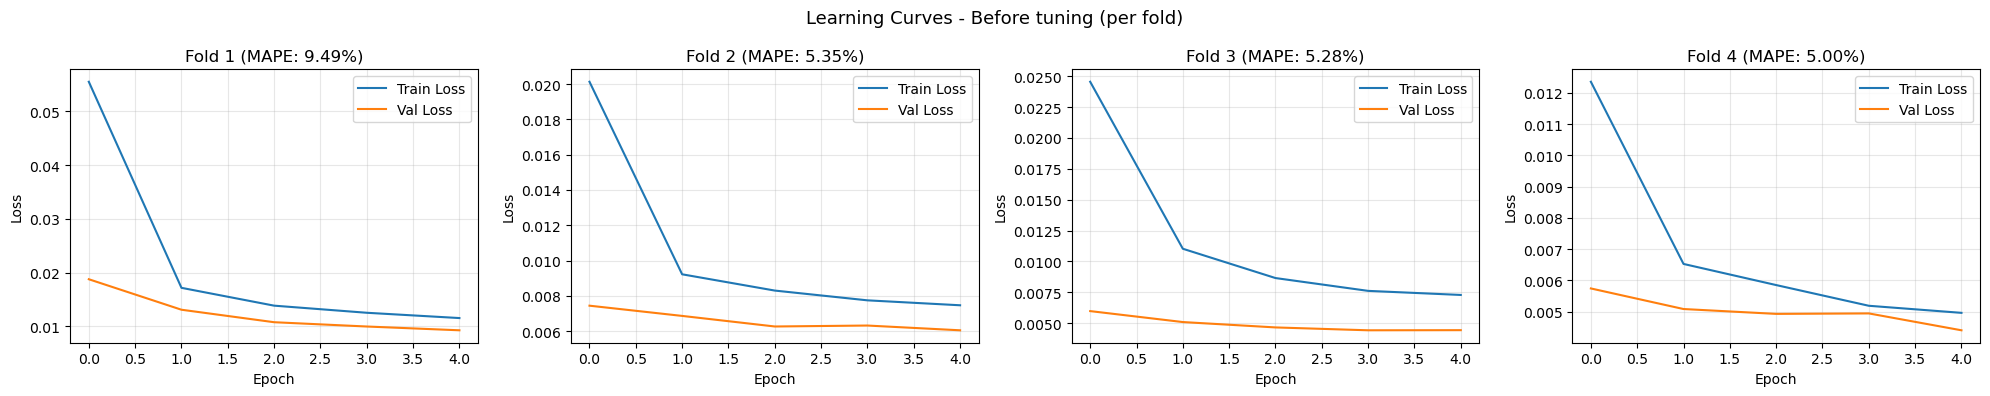

In [89]:
#plot learning curve

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for i, history in enumerate(fold_histories_12h):
    axes[i].plot(history.history['loss'], label='Train Loss')
    axes[i].plot(history.history['val_loss'], label='Val Loss')
    axes[i].set_title(f'Fold {i+1} (MAPE: {fold_results_12h[i]["mape"]:.2f}%)')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle('Learning Curves - Before tuning (per fold)', fontsize=13)
plt.tight_layout()
plt.show()

In [72]:
# Pilih fold dengan MAPE terkecil
best_fold_12h = min(fold_results_12h, key=lambda x: x['mape'])
print(f"Best fold: Fold {best_fold_12h['fold']} (MAPE: {best_fold_12h['mape']:.2f}%)")

# Retrain final model 12h dengan best hyperparameter
final_model_12h_tuned = build_model_tuner(best_fold_12h['best_hp'])

history_12h_tuned = final_model_12h_tuned.fit(
    X_train_final, y_train_final[12],
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Best fold: Fold 4 (MAPE: 5.00%)
Epoch 1/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0119 - mae: 0.0771 - val_loss: 0.0054 - val_mae: 0.0557 - learning_rate: 0.0010
Epoch 2/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 986us/step - loss: 0.0058 - mae: 0.0572 - val_loss: 0.0046 - val_mae: 0.0510 - learning_rate: 0.0010
Epoch 3/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0052 - mae: 0.0533 - val_loss: 0.0044 - val_mae: 0.0495 - learning_rate: 0.0010
Epoch 4/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0046 - mae: 0.0502 - val_loss: 0.0042 - val_mae: 0.0484 - learning_rate: 5.0000e-04
Epoch 5/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 995us/step - loss: 0.0044 - mae: 0.0487 - val_loss: 0.0041 - val_mae: 0.0475 - learning_rate: 5.0000e-04


In [73]:
# Evaluate tuned model 12h
y_pred_12h_tuned_scaled = final_model_12h_tuned.predict(X_test_final, verbose=0)
y_pred_12h_tuned = scalers_y[12].inverse_transform(y_pred_12h_tuned_scaled).flatten()

mae_12h_tuned = mean_absolute_error(y_true_12h, y_pred_12h_tuned)
rmse_12h_tuned = np.sqrt(mean_squared_error(y_true_12h, y_pred_12h_tuned))
mape_12h_tuned = np.mean(np.abs((y_true_12h - y_pred_12h_tuned) / y_true_12h)) * 100

print("Tuned Model - Horizon 12h:")
print(f"  MAE  : {mae_12h_tuned:.2f} MWh")
print(f"  RMSE : {rmse_12h_tuned:.2f} MWh")
print(f"  MAPE : {mape_12h_tuned:.2f}%")
print(f"  vs sebelumnya: {mape_12h:.2f}%")

Tuned Model - Horizon 12h:
  MAE  : 64.71 MWh
  RMSE : 87.67 MWh
  MAPE : 5.19%
  vs sebelumnya: 5.78%


In [74]:
# tuning per fold 24h
fold_results_24h = []
fold_histories_24h = []

for i, (train_start, train_end, val_start, val_end) in enumerate(splits_expanding):
    print(f"\n{'='*60}")
    print(f"Fold {i+1}: Train {train_start}–{train_end} | Val {val_start}–{val_end}")
    print(f"{'='*60}")
    
    # Prepare data fold
    X_train, X_val, y_train, y_val, scaler_y_fold = prepare_fold(
        df_fe, train_start, train_end, val_start, val_end, 'target_24h')
    
    X_train_3d = reshape_for_gru(X_train)
    X_val_3d = reshape_for_gru(X_val)
    
    # Tuning per fold
    tuner_fold = kt.BayesianOptimization(
        build_model_tuner,
        objective='val_loss',
        max_trials=5,
        directory='tuner_results',
        project_name=f'gru_24h_fold{i+1}',
        overwrite=True
    )
    
    tuner_fold.search(
        X_train_3d, y_train,
        epochs=50,
        batch_size=64,
        validation_data=(X_val_3d, y_val),
        callbacks=callbacks,
        verbose=0
    )
    
    # Ambil best hyperparameter fold ini
    best_hp = tuner_fold.get_best_hyperparameters(1)[0]
    
    # Retrain dengan best hyperparameter
    best_model_fold = tuner_fold.hypermodel.build(best_hp)
    history = best_model_fold.fit(
        X_train_3d, y_train,
        epochs=50,
        batch_size=64,
        validation_data=(X_val_3d, y_val),
        callbacks=callbacks,
        verbose=0
    )
    
    # Evaluate
    y_pred_scaled = best_model_fold.predict(X_val_3d, verbose=0).flatten()
    y_true_fold = scaler_y_fold.inverse_transform(y_val).flatten()
    y_pred_fold = scaler_y_fold.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    mape = np.mean(np.abs((y_true_fold - y_pred_fold) / y_true_fold)) * 100
    
    fold_results_24h.append({
        'fold': i+1,
        'best_hp': best_hp,
        'mape': mape
    })
    fold_histories_24h.append(history)
    
    print(f"Fold {i+1} MAPE: {mape:.2f}%")
    print(f"Best HP: layers={best_hp.get('n_layers')}, units_1={best_hp.get('units_1')}, dropout={best_hp.get('dropout')}, lr={best_hp.get('learning_rate')}")


Fold 1: Train 2015-01–2015-12 | Val 2016-01–2016-12
Fold 1 MAPE: 5.94%
Best HP: layers=1, units_1=128, dropout=0.1, lr=0.001

Fold 2: Train 2015-01–2016-12 | Val 2017-01–2017-12
Fold 2 MAPE: 5.76%
Best HP: layers=2, units_1=128, dropout=0.2, lr=0.001

Fold 3: Train 2015-01–2017-12 | Val 2018-01–2018-12
Fold 3 MAPE: 5.62%
Best HP: layers=3, units_1=32, dropout=0.2, lr=0.001

Fold 4: Train 2015-01–2018-12 | Val 2019-01–2019-12
Fold 4 MAPE: 5.85%
Best HP: layers=3, units_1=64, dropout=0.1, lr=0.001


In [75]:
# Summary best hyperparameters per fold - 24h
print("=" * 70)
print("Summary Best Hyperparameters per Fold - Horizon 24h")
print("=" * 70)
print(f"{'Fold':<6} {'n_layers':<10} {'units_1':<10} {'units_2':<10} {'dropout':<10} {'lr':<10} {'MAPE':<10}")
print("-" * 70)

for result in fold_results_24h:
    hp = result['best_hp']
    print(f"{result['fold']:<6} {hp.get('n_layers'):<10} {hp.get('units_1'):<10} {hp.get('units_2'):<10} {hp.get('dropout'):<10} {hp.get('learning_rate'):<10} {result['mape']:.2f}%")

best_fold_24h = min(fold_results_24h, key=lambda x: x['mape'])
print("-" * 70)
print(f"\nBest Fold: Fold {best_fold_24h['fold']} (MAPE: {best_fold_24h['mape']:.2f}%)")
print(f"Selected Hyperparameters:")
print(f"  n_layers     : {best_fold_24h['best_hp'].get('n_layers')}")
print(f"  units_1      : {best_fold_24h['best_hp'].get('units_1')}")
print(f"  units_2      : {best_fold_24h['best_hp'].get('units_2')}")
print(f"  dropout      : {best_fold_24h['best_hp'].get('dropout')}")
print(f"  learning_rate: {best_fold_24h['best_hp'].get('learning_rate')}")

# Retrain final model 24h
final_model_24h_tuned = build_model_tuner(best_fold_24h['best_hp'])

history_24h_tuned = final_model_24h_tuned.fit(
    X_train_final, y_train_final[24],
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Summary Best Hyperparameters per Fold - Horizon 24h
Fold   n_layers   units_1    units_2    dropout    lr         MAPE      
----------------------------------------------------------------------
1      1          128        16         0.1        0.001      5.94%
2      2          128        64         0.2        0.001      5.76%
3      3          32         32         0.2        0.001      5.62%
4      3          64         16         0.1        0.001      5.85%
----------------------------------------------------------------------

Best Fold: Fold 3 (MAPE: 5.62%)
Selected Hyperparameters:
  n_layers     : 3
  units_1      : 32
  units_2      : 32
  dropout      : 0.2
  learning_rate: 0.001
Epoch 1/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0200 - mae: 0.1029 - val_loss: 0.0063 - val_mae: 0.0612 - learning_rate: 0.0010
Epoch 2/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step - loss: 0.0091 - mae: 0.0725 - val_loss: 0.0054 - val_mae: 0.0562 - learning_rate: 0.0010
Epoch 3/50
61

In [76]:
# Evaluate tuned model 24h
y_pred_24h_tuned_scaled = final_model_24h_tuned.predict(X_test_final, verbose=0)
y_pred_24h_tuned = scalers_y[24].inverse_transform(y_pred_24h_tuned_scaled).flatten()

mae_24h_tuned = mean_absolute_error(y_true_24h, y_pred_24h_tuned)
rmse_24h_tuned = np.sqrt(mean_squared_error(y_true_24h, y_pred_24h_tuned))
mape_24h_tuned = np.mean(np.abs((y_true_24h - y_pred_24h_tuned) / y_true_24h)) * 100

print("Tuned Model - Horizon 24h:")
print(f"  MAE  : {mae_24h_tuned:.2f} MWh")
print(f"  RMSE : {rmse_24h_tuned:.2f} MWh")
print(f"  MAPE : {mape_24h_tuned:.2f}%")
print(f"  vs sebelumnya: {mape_24h:.2f}%")

Tuned Model - Horizon 24h:
  MAE  : 78.98 MWh
  RMSE : 103.71 MWh
  MAPE : 6.08%
  vs sebelumnya: 5.67%


In [77]:
# tuning per fold 6h
fold_results_6h = []
fold_histories_6h = []

for i, (train_start, train_end, val_start, val_end) in enumerate(splits_expanding):
    print(f"\n{'='*60}")
    print(f"Fold {i+1}: Train {train_start}–{train_end} | Val {val_start}–{val_end}")
    print(f"{'='*60}")
    
    # Prepare data fold
    X_train, X_val, y_train, y_val, scaler_y_fold = prepare_fold(
        df_fe, train_start, train_end, val_start, val_end, 'target_6h')
    
    X_train_3d = reshape_for_gru(X_train)
    X_val_3d = reshape_for_gru(X_val)
    
    # Tuning per fold
    tuner_fold = kt.BayesianOptimization(
        build_model_tuner,
        objective='val_loss',
        max_trials=5,
        directory='tuner_results',
        project_name=f'gru_6h_fold{i+1}',
        overwrite=True
    )
    
    tuner_fold.search(
        X_train_3d, y_train,
        epochs=50,
        batch_size=64,
        validation_data=(X_val_3d, y_val),
        callbacks=callbacks,
        verbose=0
    )
    
    # Ambil best hyperparameter fold ini
    best_hp = tuner_fold.get_best_hyperparameters(1)[0]
    
    # Retrain dengan best hyperparameter
    best_model_fold = tuner_fold.hypermodel.build(best_hp)
    history = best_model_fold.fit(
        X_train_3d, y_train,
        epochs=50,
        batch_size=64,
        validation_data=(X_val_3d, y_val),
        callbacks=callbacks,
        verbose=0
    )
    
    # Evaluate
    y_pred_scaled = best_model_fold.predict(X_val_3d, verbose=0).flatten()
    y_true_fold = scaler_y_fold.inverse_transform(y_val).flatten()
    y_pred_fold = scaler_y_fold.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    mape = np.mean(np.abs((y_true_fold - y_pred_fold) / y_true_fold)) * 100
    
    fold_results_6h.append({
        'fold': i+1,
        'best_hp': best_hp,
        'mape': mape
    })
    fold_histories_6h.append(history)
    
    print(f"Fold {i+1} MAPE: {mape:.2f}%")
    print(f"Best HP: layers={best_hp.get('n_layers')}, units_1={best_hp.get('units_1')}, dropout={best_hp.get('dropout')}, lr={best_hp.get('learning_rate')}")


Fold 1: Train 2015-01–2015-12 | Val 2016-01–2016-12
Fold 1 MAPE: 6.02%
Best HP: layers=3, units_1=128, dropout=0.1, lr=0.001

Fold 2: Train 2015-01–2016-12 | Val 2017-01–2017-12
Fold 2 MAPE: 6.91%
Best HP: layers=3, units_1=32, dropout=0.3, lr=0.001

Fold 3: Train 2015-01–2017-12 | Val 2018-01–2018-12
Fold 3 MAPE: 6.50%
Best HP: layers=3, units_1=32, dropout=0.2, lr=0.0005

Fold 4: Train 2015-01–2018-12 | Val 2019-01–2019-12
Fold 4 MAPE: 4.51%
Best HP: layers=2, units_1=64, dropout=0.1, lr=0.001


In [78]:
# Summary + Retrain final model 6h
print("=" * 70)
print("Summary Best Hyperparameters per Fold - Horizon 6h")
print("=" * 70)
print(f"{'Fold':<6} {'n_layers':<10} {'units_1':<10} {'units_2':<10} {'dropout':<10} {'lr':<10} {'MAPE':<10}")
print("-" * 70)

for result in fold_results_6h:
    hp = result['best_hp']
    print(f"{result['fold']:<6} {hp.get('n_layers'):<10} {hp.get('units_1'):<10} {hp.get('units_2'):<10} {hp.get('dropout'):<10} {hp.get('learning_rate'):<10} {result['mape']:.2f}%")

best_fold_6h = min(fold_results_6h, key=lambda x: x['mape'])
print("-" * 70)
print(f"\nBest Fold: Fold {best_fold_6h['fold']} (MAPE: {best_fold_6h['mape']:.2f}%)")
print(f"Selected Hyperparameters:")
print(f"  n_layers     : {best_fold_6h['best_hp'].get('n_layers')}")
print(f"  units_1      : {best_fold_6h['best_hp'].get('units_1')}")
print(f"  units_2      : {best_fold_6h['best_hp'].get('units_2')}")
print(f"  dropout      : {best_fold_6h['best_hp'].get('dropout')}")
print(f"  learning_rate: {best_fold_6h['best_hp'].get('learning_rate')}")

# Retrain final model 6h
final_model_6h_tuned = build_model_tuner(best_fold_6h['best_hp'])

history_6h_tuned = final_model_6h_tuned.fit(
    X_train_final, y_train_final[6],
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Summary Best Hyperparameters per Fold - Horizon 6h
Fold   n_layers   units_1    units_2    dropout    lr         MAPE      
----------------------------------------------------------------------
1      3          128        64         0.1        0.001      6.02%
2      3          32         16         0.3        0.001      6.91%
3      3          32         32         0.2        0.0005     6.50%
4      2          64         64         0.1        0.001      4.51%
----------------------------------------------------------------------

Best Fold: Fold 4 (MAPE: 4.51%)
Selected Hyperparameters:
  n_layers     : 2
  units_1      : 64
  units_2      : 64
  dropout      : 0.1
  learning_rate: 0.001
Epoch 1/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0102 - mae: 0.0736 - val_loss: 0.0036 - val_mae: 0.0476 - learning_rate: 0.0010
Epoch 2/50
614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 950us/step - loss: 0.0040 - mae: 0.0493 - val_loss: 0.0034 - val_mae: 0.0465 - learning_rate: 0.0010
Epoch 3/50
614

In [79]:
# Evaluate tuned model 6h
y_pred_6h_tuned_scaled = final_model_6h_tuned.predict(X_test_final, verbose=0)
y_pred_6h_tuned = scalers_y[6].inverse_transform(y_pred_6h_tuned_scaled).flatten()

mae_6h_tuned = mean_absolute_error(y_true_6h, y_pred_6h_tuned)
rmse_6h_tuned = np.sqrt(mean_squared_error(y_true_6h, y_pred_6h_tuned))
mape_6h_tuned = np.mean(np.abs((y_true_6h - y_pred_6h_tuned) / y_true_6h)) * 100

print("Tuned Model - Horizon 6h:")
print(f"  MAE  : {mae_6h_tuned:.2f} MWh")
print(f"  RMSE : {rmse_6h_tuned:.2f} MWh")
print(f"  MAPE : {mape_6h_tuned:.2f}%")
print(f"  vs sebelumnya: {mape_6h:.2f}%")

Tuned Model - Horizon 6h:
  MAE  : 62.31 MWh
  RMSE : 82.75 MWh
  MAPE : 4.86%
  vs sebelumnya: 5.30%


In [82]:
import shap
print(shap.__version__)

0.51.0



Computing SHAP values - Horizon 6h...


PermutationExplainer explainer: 101it [00:58,  1.48it/s]                        
/var/folders/_j/r_89yc7x1t75cq57frl6chnm0000gn/T/ipykernel_36659/4062042428.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, explain_2d,


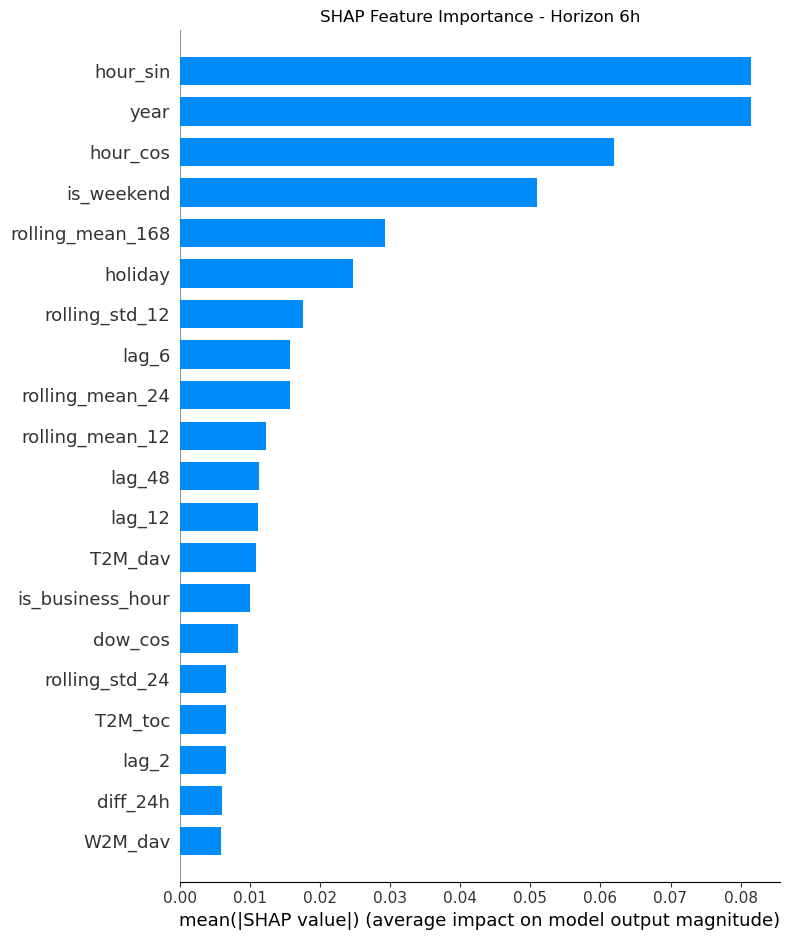

/var/folders/_j/r_89yc7x1t75cq57frl6chnm0000gn/T/ipykernel_36659/4062042428.py:45: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, explain_2d,


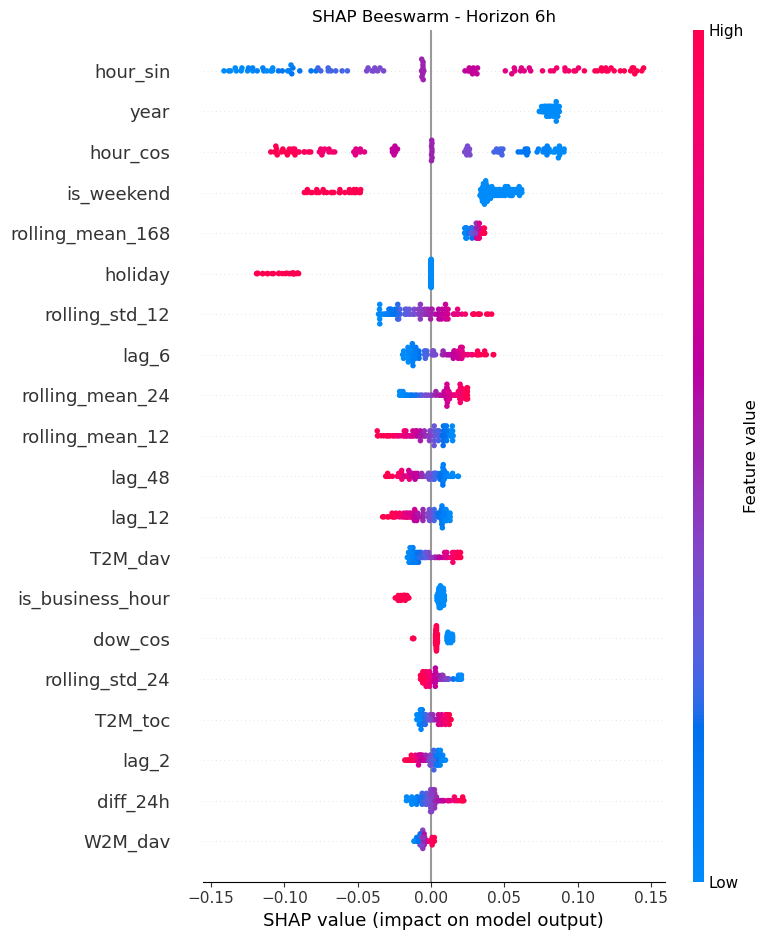


Computing SHAP values - Horizon 12h...


PermutationExplainer explainer: 101it [01:04,  1.32it/s]                        
/var/folders/_j/r_89yc7x1t75cq57frl6chnm0000gn/T/ipykernel_36659/4062042428.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, explain_2d,


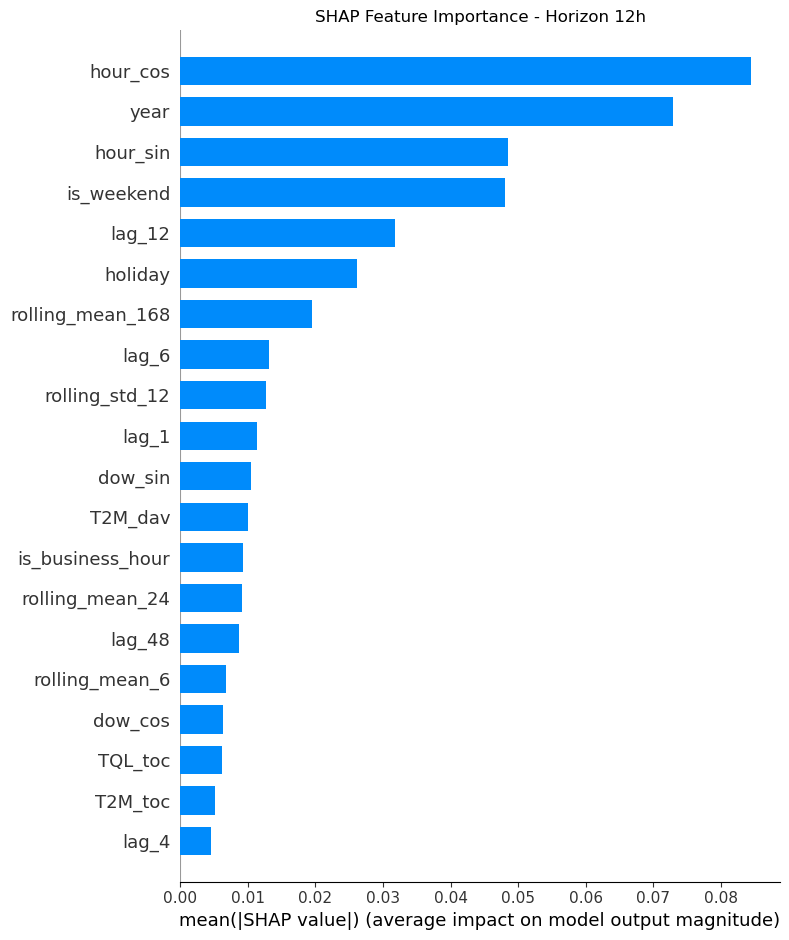

/var/folders/_j/r_89yc7x1t75cq57frl6chnm0000gn/T/ipykernel_36659/4062042428.py:45: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, explain_2d,


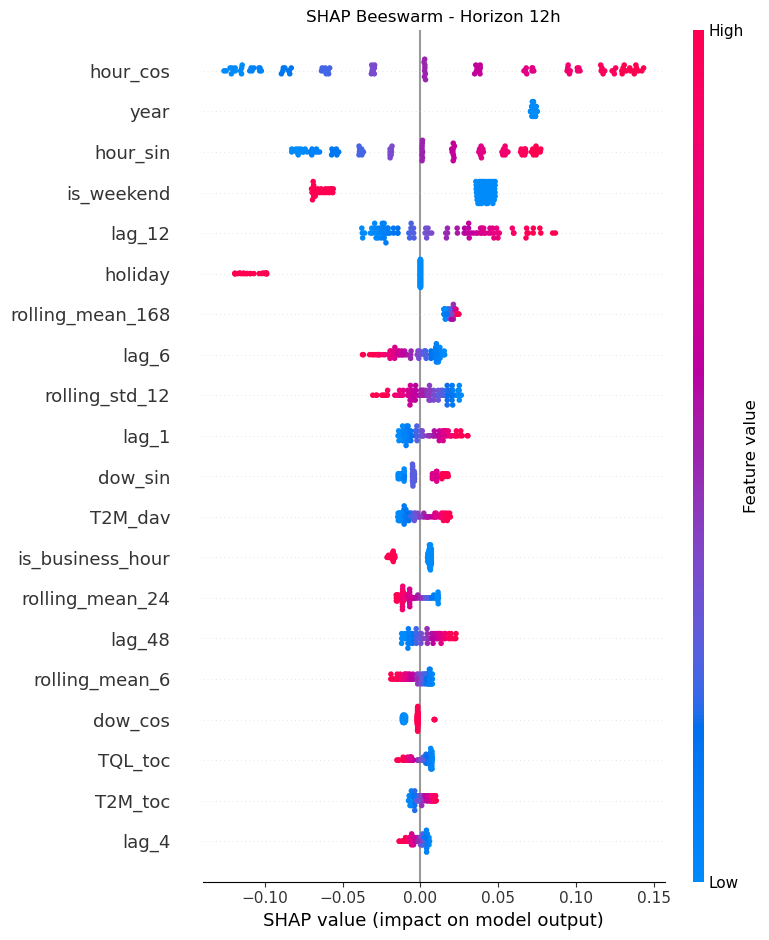


Computing SHAP values - Horizon 24h...


PermutationExplainer explainer: 101it [00:57,  1.46it/s]                        
/var/folders/_j/r_89yc7x1t75cq57frl6chnm0000gn/T/ipykernel_36659/4062042428.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, explain_2d,


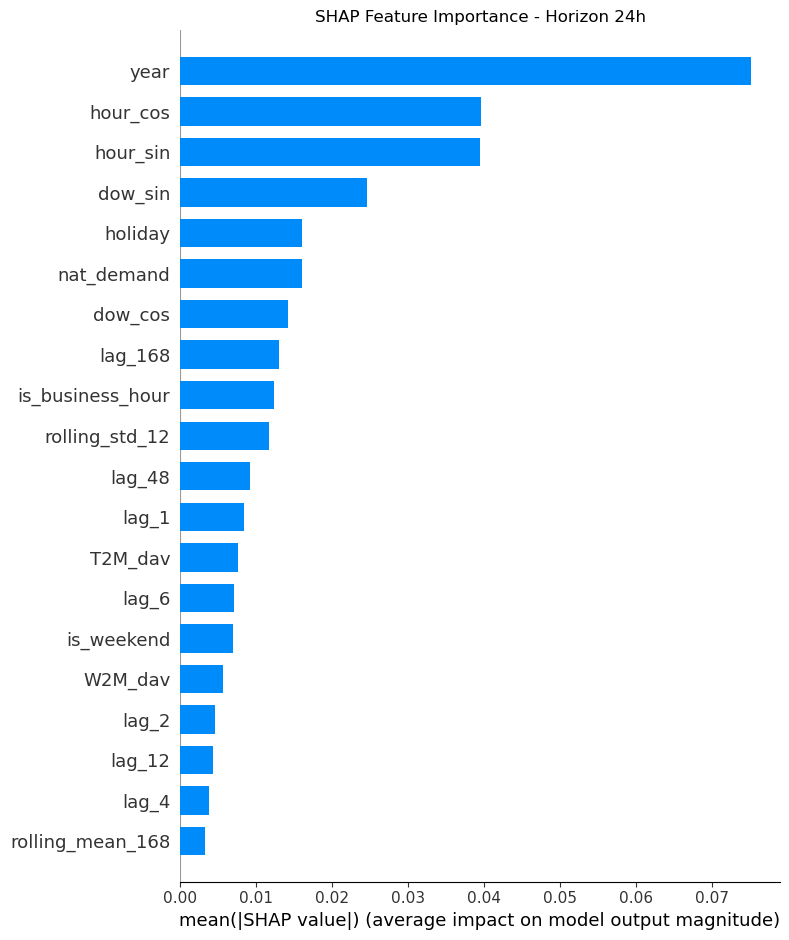

/var/folders/_j/r_89yc7x1t75cq57frl6chnm0000gn/T/ipykernel_36659/4062042428.py:45: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, explain_2d,


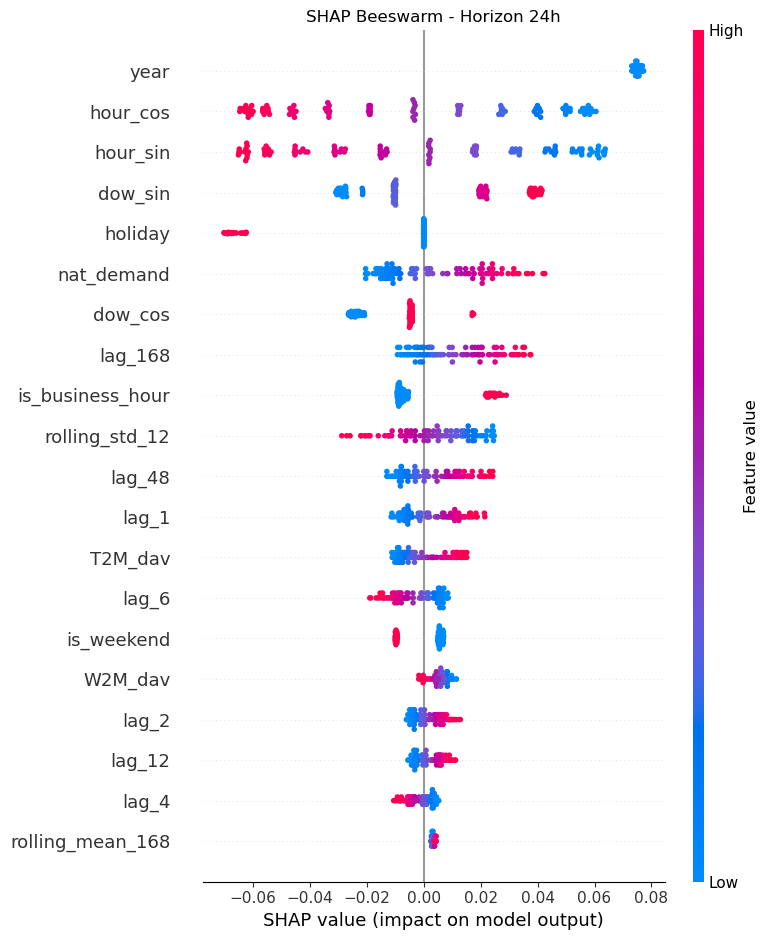

In [83]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Pakai subset kecil supaya cepat
background = X_train_final[:200]
explain_samples = X_test_final[:100]

# Reshape ke 2D untuk SHAP (n_samples, n_features)
background_2d = background.reshape(background.shape[0], -1)
explain_2d = explain_samples.reshape(explain_samples.shape[0], -1)

# Feature names
feature_names = feature_cols

models = {
    '6h': final_model_6h_tuned,
    '12h': final_model_12h_tuned,
    '24h': final_model_24h_tuned
}

for horizon, model in models.items():
    print(f"\nComputing SHAP values - Horizon {horizon}...")
    
    # Wrapper function untuk SHAP
    def model_predict(x):
        x_3d = x.reshape(x.shape[0], 1, len(feature_cols))
        return model.predict(x_3d, verbose=0).flatten()
    
    explainer = shap.Explainer(model_predict, background_2d)
    shap_values = explainer(explain_2d)
    
    # Summary plot bar
    plt.figure()
    shap.summary_plot(shap_values, explain_2d, 
                      feature_names=feature_names,
                      plot_type='bar',
                      show=False)
    plt.title(f'SHAP Feature Importance - Horizon {horizon}')
    plt.tight_layout()
    plt.show()
    
    # Beeswarm plot
    plt.figure()
    shap.summary_plot(shap_values, explain_2d,
                      feature_names=feature_names,
                      show=False)
    plt.title(f'SHAP Beeswarm - Horizon {horizon}')
    plt.tight_layout()
    plt.show()

In [85]:
# Summary RMSE dan MAPE - Before vs After Tuning
print("=" * 75)
print(f"{'Horizon':<10} {'RMSE Before':>12} {'RMSE After':>12} {'MAPE Before':>12} {'MAPE After':>12}")
print("-" * 75)

print(f"{'6h':<10} {rmse_6h:>12.2f} {rmse_6h_tuned:>12.2f} {mape_6h:>12.2f}% {mape_6h_tuned:>11.2f}%")
print(f"{'12h':<10} {rmse_12h:>12.2f} {rmse_12h_tuned:>12.2f} {mape_12h:>12.2f}% {mape_12h_tuned:>11.2f}%")
print(f"{'24h':<10} {rmse_24h:>12.2f} {rmse_24h_tuned:>12.2f} {mape_24h:>12.2f}% {mape_24h_tuned:>11.2f}%")
print("=" * 75)

Horizon     RMSE Before   RMSE After  MAPE Before   MAPE After
---------------------------------------------------------------------------
6h                86.27        82.75         5.30%        4.86%
12h               93.74        87.67         5.78%        5.19%
24h               97.83       103.71         5.67%        6.08%


In [86]:
# Summary best hyperparameters per horizon
for horizon, fold_results in [('6h', fold_results_6h), ('12h', fold_results_12h), ('24h', fold_results_24h)]:
    best_fold = min(fold_results, key=lambda x: x['mape'])
    hp = best_fold['best_hp']
    
    # Hitung RMSE dari best fold
    best_rmse = None
    for result in fold_results:
        if result['fold'] == best_fold['fold']:
            best_rmse = result.get('rmse', None)
    
    print(f"Best Hyperparameters ({horizon}): {{")
    print(f"  'n_layers': {hp.get('n_layers')},")
    print(f"  'units_1': {hp.get('units_1')},")
    print(f"  'units_2': {hp.get('units_2')},")
    print(f"  'dropout': {hp.get('dropout')},")
    print(f"  'learning_rate': {hp.get('learning_rate')}")
    print(f"}}")
    print(f"Best Fold: Fold {best_fold['fold']} | MAPE: {best_fold['mape']:.2f}%")
    print()

Best Hyperparameters (6h): {
  'n_layers': 2,
  'units_1': 64,
  'units_2': 64,
  'dropout': 0.1,
  'learning_rate': 0.001
}
Best Fold: Fold 4 | MAPE: 4.51%

Best Hyperparameters (12h): {
  'n_layers': 2,
  'units_1': 128,
  'units_2': 32,
  'dropout': 0.1,
  'learning_rate': 0.001
}
Best Fold: Fold 4 | MAPE: 5.00%

Best Hyperparameters (24h): {
  'n_layers': 3,
  'units_1': 32,
  'units_2': 32,
  'dropout': 0.2,
  'learning_rate': 0.001
}
Best Fold: Fold 3 | MAPE: 5.62%



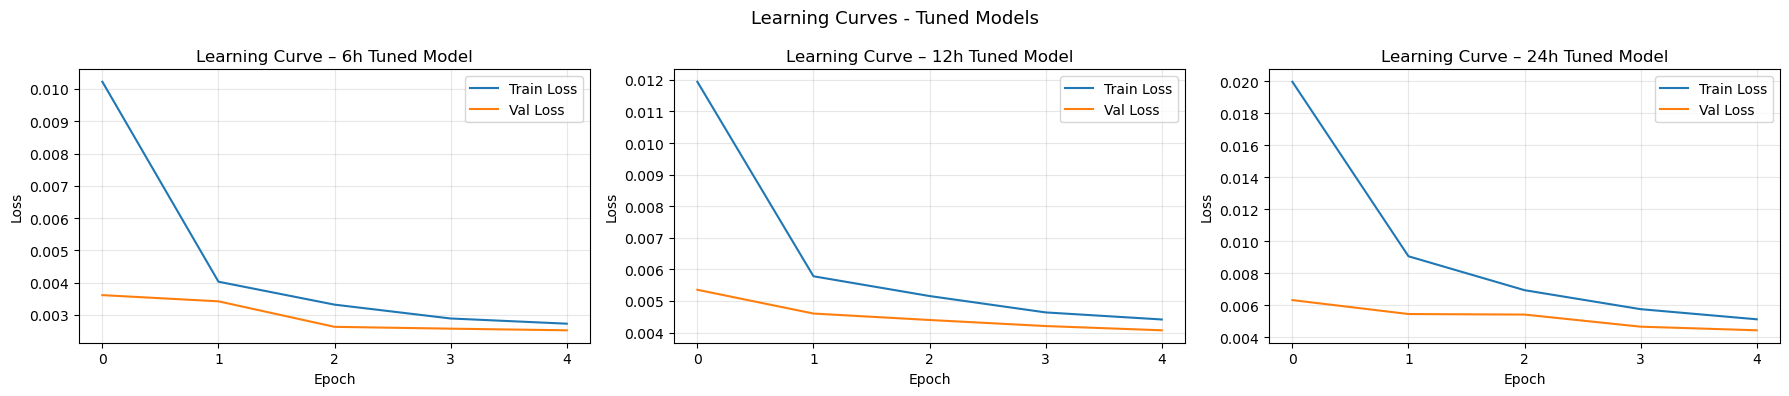

In [87]:
# Learning Curves - Tuned Models
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

histories = [history_6h_tuned, history_12h_tuned, history_24h_tuned]
horizons = ['6h', '12h', '24h']

for i, (history, horizon) in enumerate(zip(histories, horizons)):
    axes[i].plot(history.history['loss'], label='Train Loss')
    axes[i].plot(history.history['val_loss'], label='Val Loss')
    axes[i].set_title(f'Learning Curve – {horizon} Tuned Model')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle('Learning Curves - Tuned Models', fontsize=13)
plt.tight_layout()
plt.show()

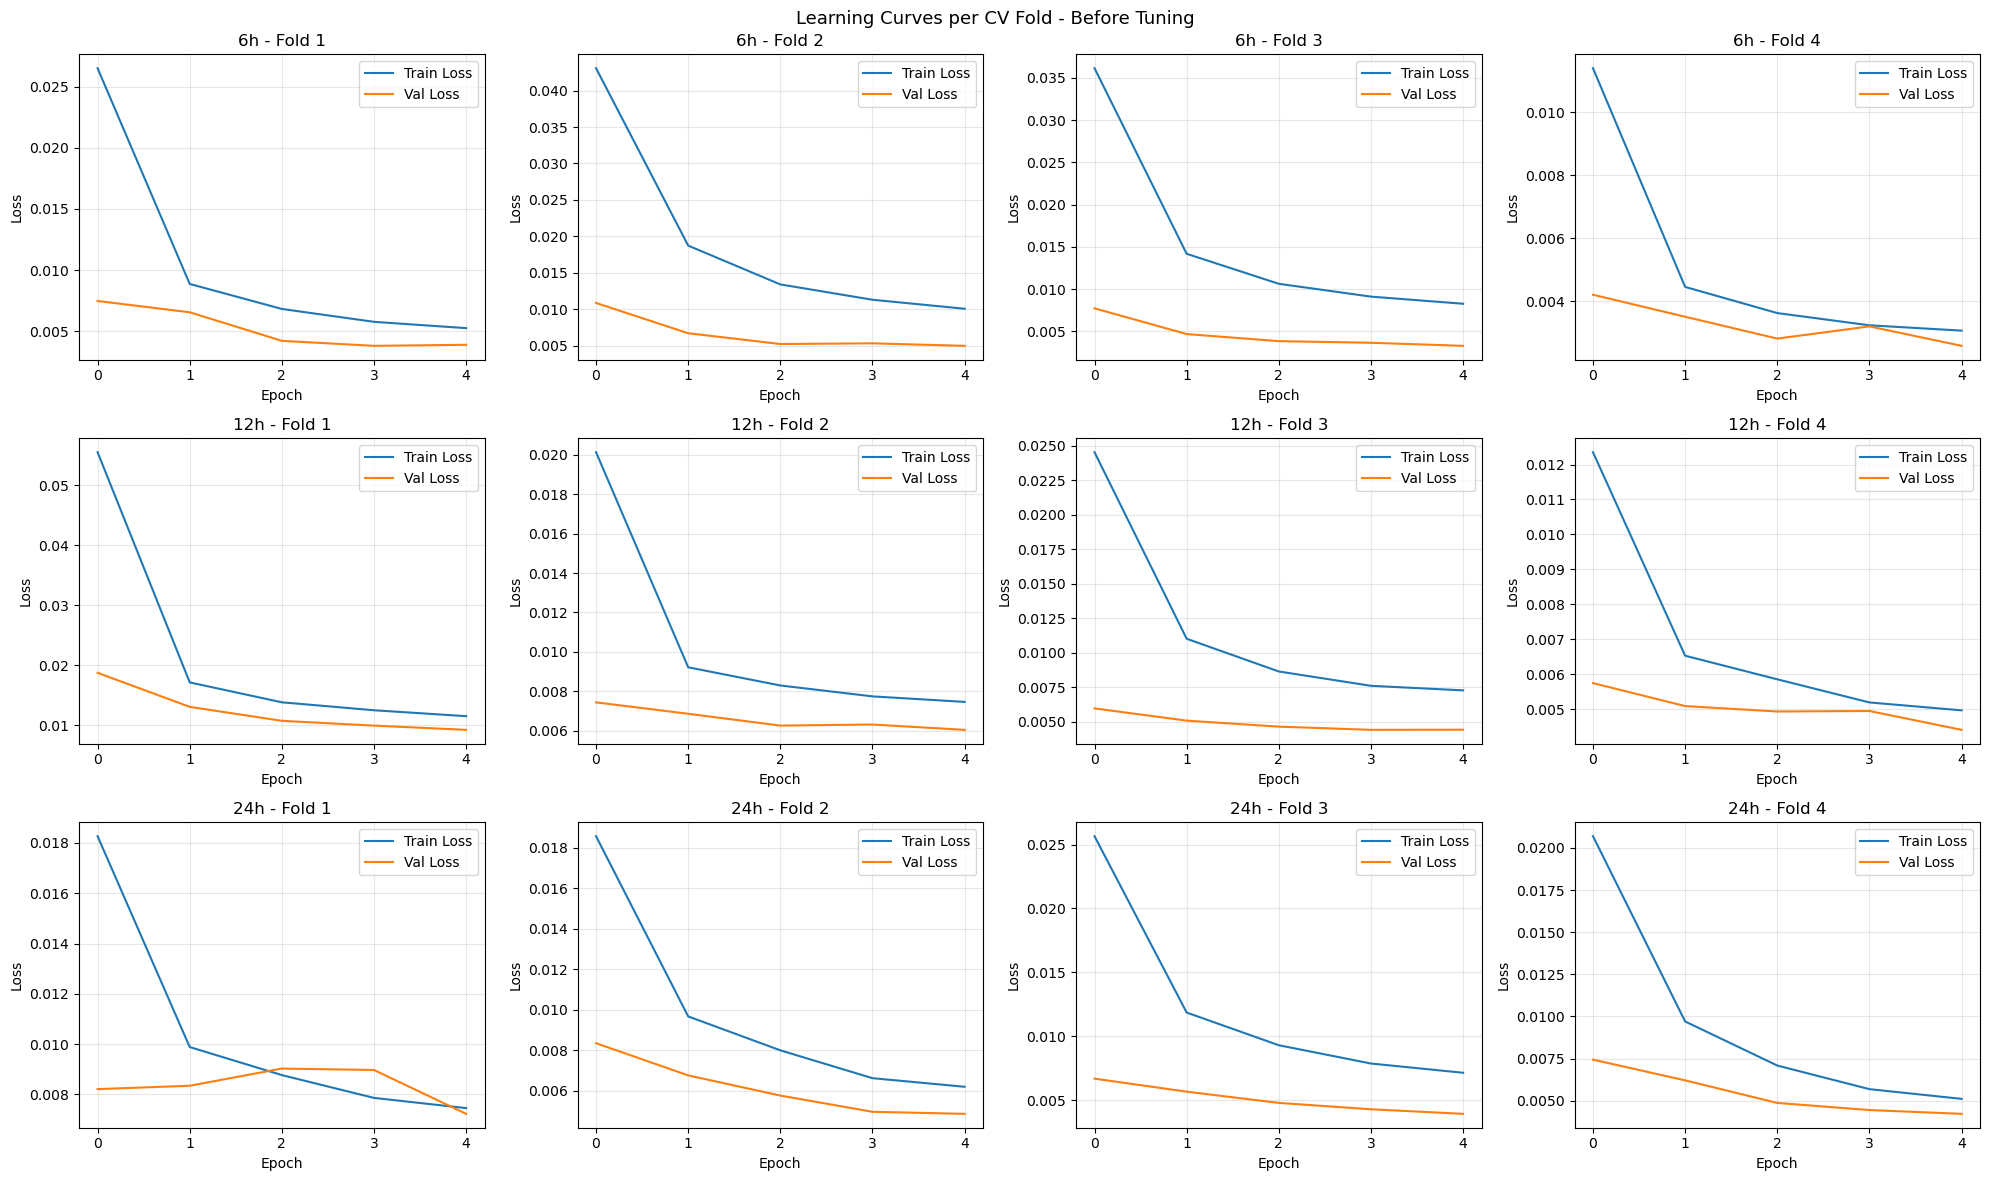

In [88]:
# Learning Curves per CV fold - sebelum tuning
fig, axes = plt.subplots(3, 4, figsize=(20, 12))

fold_histories = [fold_histories_6h, fold_histories_12h, fold_histories_24h]
horizons = ['6h', '12h', '24h']

for row, (histories, horizon) in enumerate(zip(fold_histories, horizons)):
    for col, history in enumerate(histories):
        axes[row, col].plot(history.history['loss'], label='Train Loss')
        axes[row, col].plot(history.history['val_loss'], label='Val Loss')
        axes[row, col].set_title(f'{horizon} - Fold {col+1}')
        axes[row, col].set_xlabel('Epoch')
        axes[row, col].set_ylabel('Loss')
        axes[row, col].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        axes[row, col].legend()
        axes[row, col].grid(alpha=0.3)

plt.suptitle('Learning Curves per CV Fold - Before Tuning', fontsize=13)
plt.tight_layout()
plt.show()

## tuning whole dataset

In [ ]:
def build_model_tuner(hp):
    units_1 = hp.Choice('units_1', values=[32, 64, 128])
    units_2 = hp.Choice('units_2', values=[16, 32, 64])
    dropout_rate = hp.Choice('dropout', values=[0.1, 0.2, 0.3])
    learning_rate = hp.Choice('learning_rate', values=[0.001, 0.0005, 0.0001])
    n_layers = hp.Choice('n_layers', values=[1, 2, 3])
    
    inputs = Input(shape=(X_train_final.shape[1], X_train_final.shape[2]))
    x = GRU(units_1, return_sequences=(n_layers > 1))(inputs)
    x = Dropout(dropout_rate)(x)
    
    if n_layers >= 2:
        x = GRU(units_2, return_sequences=(n_layers > 2))(x)
        x = Dropout(dropout_rate)(x)
    
    if n_layers >= 3:
        x = GRU(units_2 // 2, return_sequences=False)(x)
        x = Dropout(dropout_rate)(x)
    
    outputs = Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

In [ ]:
# Tuning - Horizon 1h
tuner_1h = kt.BayesianOptimization(
    build_model_tuner,
    objective='val_loss',
    max_trials=10,
    directory='tuner_results',
    project_name='gru_tuning_1h',
    overwrite=True
)

tuner_1h.search(
    X_train_final, y_train_final[1],
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
# Lihat semua trials
tuner_1h.results_summary()

# Lihat best hyperparameters
best_hps_1h = tuner_1h.get_best_hyperparameters(1)[0]
print("\nBest Hyperparameters 1h:")
print(f"  units_1      : {best_hps_1h.get('units_1')}")
print(f"  units_2      : {best_hps_1h.get('units_2')}")
print(f"  dropout      : {best_hps_1h.get('dropout')}")
print(f"  learning_rate: {best_hps_1h.get('learning_rate')}")
print(f"  n_layers     : {best_hps_1h.get('n_layers')}")

In [ ]:
# Tuning - Horizon 6h
tuner_6h = kt.BayesianOptimization(
    build_model_tuner,
    objective='val_loss',
    max_trials=10,
    directory='tuner_results',
    project_name='gru_tuning_6h',
    overwrite=True
)

tuner_6h.search(
    X_train_final, y_train_final[6],
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
tuner_6h.results_summary()

best_hps_6h = tuner_6h.get_best_hyperparameters(1)[0]
print("\nBest Hyperparameters 6h:")
print(f"  units_1      : {best_hps_6h.get('units_1')}")
print(f"  units_2      : {best_hps_6h.get('units_2')}")
print(f"  dropout      : {best_hps_6h.get('dropout')}")
print(f"  learning_rate: {best_hps_6h.get('learning_rate')}")
print(f"  n_layers     : {best_hps_6h.get('n_layers')}")

In [ ]:
# Tuning - Horizon 12h
tuner_12h = kt.BayesianOptimization(
    build_model_tuner,
    objective='val_loss',
    max_trials=10,
    directory='tuner_results',
    project_name='gru_tuning_12h',
    overwrite=True
)

tuner_12h.search(
    X_train_final, y_train_final[12],
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
tuner_12h.results_summary()

best_hps_12h = tuner_12h.get_best_hyperparameters(1)[0]
print("\nBest Hyperparameters 12h:")
print(f"  units_1      : {best_hps_12h.get('units_1')}")
print(f"  units_2      : {best_hps_12h.get('units_2')}")
print(f"  dropout      : {best_hps_12h.get('dropout')}")
print(f"  learning_rate: {best_hps_12h.get('learning_rate')}")
print(f"  n_layers     : {best_hps_12h.get('n_layers')}")

In [ ]:
# Tuning - Horizon 24h
tuner_24h = kt.BayesianOptimization(
    build_model_tuner,
    objective='val_loss',
    max_trials=10,
    directory='tuner_results',
    project_name='gru_tuning_24h',
    overwrite=True
)

tuner_24h.search(
    X_train_final, y_train_final[24],
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
tuner_24h.results_summary()

best_hps_24h = tuner_24h.get_best_hyperparameters(1)[0]
print("\nBest Hyperparameters 24h:")
print(f"  units_1      : {best_hps_24h.get('units_1')}")
print(f"  units_2      : {best_hps_24h.get('units_2')}")
print(f"  dropout      : {best_hps_24h.get('dropout')}")
print(f"  learning_rate: {best_hps_24h.get('learning_rate')}")
print(f"  n_layers     : {best_hps_24h.get('n_layers')}")

In [ ]:
# Retrain Final Model 1h dengan best hyperparameters
best_model_1h = tuner_1h.hypermodel.build(best_hps_1h)

history_1h_tuned = best_model_1h.fit(
    X_train_final, y_train_final[1],
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
# Evaluate tuned model 1h
y_pred_1h_tuned_scaled = best_model_1h.predict(X_test_final, verbose=0)
y_pred_1h_tuned = scalers_y[1].inverse_transform(y_pred_1h_tuned_scaled).flatten()

mae_1h_tuned = mean_absolute_error(y_true_1h, y_pred_1h_tuned)
rmse_1h_tuned = np.sqrt(mean_squared_error(y_true_1h, y_pred_1h_tuned))
mape_1h_tuned = np.mean(np.abs((y_true_1h - y_pred_1h_tuned) / y_true_1h)) * 100

print("Tuned Model - Horizon 1h:")
print(f"  MAE  : {mae_1h_tuned:.2f} MWh")
print(f"  RMSE : {rmse_1h_tuned:.2f} MWh")
print(f"  MAPE : {mape_1h_tuned:.2f}%")
print(f"  vs sebelumnya: {mape_1h:.2f}%")

In [ ]:
# Retrain Final Model 6h dengan best hyperparameters
best_model_6h = tuner_6h.hypermodel.build(best_hps_6h)

history_6h_tuned = best_model_6h.fit(
    X_train_final, y_train_final[6],
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
# Evaluate tuned model 6h
y_pred_6h_tuned_scaled = best_model_6h.predict(X_test_final, verbose=0)
y_pred_6h_tuned = scalers_y[6].inverse_transform(y_pred_6h_tuned_scaled).flatten()

mae_6h_tuned = mean_absolute_error(y_true_6h, y_pred_6h_tuned)
rmse_6h_tuned = np.sqrt(mean_squared_error(y_true_6h, y_pred_6h_tuned))
mape_6h_tuned = np.mean(np.abs((y_true_6h - y_pred_6h_tuned) / y_true_6h)) * 100

print("Tuned Model - Horizon 6h:")
print(f"  MAE  : {mae_6h_tuned:.2f} MWh")
print(f"  RMSE : {rmse_6h_tuned:.2f} MWh")
print(f"  MAPE : {mape_6h_tuned:.2f}%")
print(f"  vs sebelumnya: {mape_6h:.2f}%")

In [ ]:
# Retrain Final Model 12h dengan best hyperparameters
best_model_12h = tuner_12h.hypermodel.build(best_hps_12h)

history_12h_tuned = best_model_12h.fit(
    X_train_final, y_train_final[12],
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
# Evaluate tuned model 12h
y_pred_12h_tuned_scaled = best_model_12h.predict(X_test_final, verbose=0)
y_pred_12h_tuned = scalers_y[12].inverse_transform(y_pred_12h_tuned_scaled).flatten()

mae_12h_tuned = mean_absolute_error(y_true_12h, y_pred_12h_tuned)
rmse_12h_tuned = np.sqrt(mean_squared_error(y_true_12h, y_pred_12h_tuned))
mape_12h_tuned = np.mean(np.abs((y_true_12h - y_pred_12h_tuned) / y_true_12h)) * 100

print("Tuned Model - Horizon 12h:")
print(f"  MAE  : {mae_12h_tuned:.2f} MWh")
print(f"  RMSE : {rmse_12h_tuned:.2f} MWh")
print(f"  MAPE : {mape_12h_tuned:.2f}%")
print(f"  vs sebelumnya: {mape_12h:.2f}%")

## retrain w/ best hyperparameter

In [ ]:
# Retrain Final Model 24h dengan best hyperparameters
best_model_24h = tuner_24h.hypermodel.build(best_hps_24h)

history_24h_tuned = best_model_24h.fit(
    X_train_final, y_train_final[24],
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
# Evaluate tuned model 24h
y_pred_24h_tuned_scaled = best_model_24h.predict(X_test_final, verbose=0)
y_pred_24h_tuned = scalers_y[24].inverse_transform(y_pred_24h_tuned_scaled).flatten()

mae_24h_tuned = mean_absolute_error(y_true_24h, y_pred_24h_tuned)
rmse_24h_tuned = np.sqrt(mean_squared_error(y_true_24h, y_pred_24h_tuned))
mape_24h_tuned = np.mean(np.abs((y_true_24h - y_pred_24h_tuned) / y_true_24h)) * 100

print("Tuned Model - Horizon 24h:")
print(f"  MAE  : {mae_24h_tuned:.2f} MWh")
print(f"  RMSE : {rmse_24h_tuned:.2f} MWh")
print(f"  MAPE : {mape_24h_tuned:.2f}%")
print(f"  vs sebelumnya: {mape_24h:.2f}%")

In [ ]:
# Cek dengan scaler yang bener
y_pred_1h_tuned_scaled = best_model_1h.predict(X_test_final, verbose=0).flatten()

dummy_pred = np.zeros((len(y_pred_1h_tuned_scaled), len(feature_cols)))
dummy_pred[:, 0] = y_pred_1h_tuned_scaled

y_pred_1h_tuned = scaler_X_final.inverse_transform(dummy_pred)[:, 0]

mape_check = np.mean(np.abs((y_true_1h - y_pred_1h_tuned) / y_true_1h)) * 100
print(f"MAPE 1h tuned: {mape_check:.2f}%")

In [ ]:
print(X_test_final.shape)
print(y_true_1h.shape)
print(y_pred_1h_tuned_scaled.shape)
print(y_pred_1h_tuned_scaled[:5])
print(y_true_1h[:5])

In [ ]:
# Flatten y_true dulu
y_true_1h_flat = y_true_1h.flatten()

# Inverse transform prediksi dengan scaler yang bener
y_pred_1h_tuned = scaler_y_final.inverse_transform(
    y_pred_1h_tuned_scaled.reshape(-1, 1)
).flatten()

mape_check = np.mean(np.abs((y_true_1h_flat - y_pred_1h_tuned) / y_true_1h_flat)) * 100
print(f"MAPE 1h tuned: {mape_check:.2f}%")
print(f"y_pred sample: {y_pred_1h_tuned[:5]}")

In [ ]:
y_true_6h_flat = y_true_6h.flatten()

y_pred_6h_tuned = scaler_y_final.inverse_transform(
    y_pred_6h_tuned_scaled.reshape(-1, 1)
).flatten()

mape_6h_check = np.mean(np.abs((y_true_6h_flat - y_pred_6h_tuned) / y_true_6h_flat)) * 100
print(f"MAPE 6h tuned: {mape_6h_check:.2f}%")
print(f"y_pred sample: {y_pred_6h_tuned[:5]}")

# Sliding & Expanding

In [ ]:
# # Sliding window - 12h horizon
# results_sliding_12h = run_cv(splits, 'target_12h', 'Sliding Window')

In [ ]:
# # Expanding window - 12h horizon
# results_expanding_12h = run_cv(splits_expanding, 'target_12h', 'Expanding Window')

In [ ]:
# # Sliding window - 24h horizon
# results_sliding_24h = run_cv(splits, 'target_24h', 'Sliding Window')

In [ ]:
# # Expanding window - 24h horizon
# results_expanding_24h = run_cv(splits_expanding, 'target_24h', 'Expanding Window')

In [ ]:
# result comparison

# Add labels
results_sliding_12h['horizon'] = '12h'
results_sliding_12h['cv'] = 'Sliding'
results_expanding_12h['horizon'] = '12h'
results_expanding_12h['cv'] = 'Expanding'
results_sliding_24h['horizon'] = '24h'
results_sliding_24h['cv'] = 'Sliding'
results_expanding_24h['horizon'] = '24h'
results_expanding_24h['cv'] = 'Expanding'

# Combine
all_results = pd.concat([results_sliding_12h, results_expanding_12h,
                         results_sliding_24h, results_expanding_24h])

# Summary: mean per group
summary = all_results.groupby(['horizon', 'cv'])[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print(summary)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 5, figsize=(24, 8))
configs = [
    (splits, 'target_12h', 'Sliding Window - 12h'),
    (splits, 'target_24h', 'Sliding Window - 24h'),
]

for row, (split_list, target_col, title) in enumerate(configs):
    for col, (train_start, train_end, val_start, val_end) in enumerate(split_list):
        ax = axes[row, col]
        
        train = df_fe.loc[train_start:train_end]['nat_demand'].resample('D').mean()
        val_true = df_fe.loc[val_start:val_end][target_col].resample('D').mean()
        
        ax.plot(train.index, train.values, color='steelblue', linewidth=0.8)
        ax.plot(val_true.index, val_true.values, color='red', linewidth=0.8)
        ax.set_title(f'{title}\nFold {col+1}', fontsize=8)
        ax.tick_params(axis='x', rotation=45, labelsize=6)
        ax.tick_params(axis='y', labelsize=6)

blue_patch = mpatches.Patch(color='steelblue', label='Training')
red_patch = mpatches.Patch(color='red', label='Validation')
fig.legend(handles=[blue_patch, red_patch], loc='upper right', fontsize=10)
plt.suptitle('Sliding Window CV', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Engineering (window sequence)

In [ ]:
# Feature Engineering for Sequence Window approach
df_seq = df_clean.copy()

# Temporal features
df_seq['hour'] = df_seq.index.hour
df_seq['dayofweek'] = df_seq.index.dayofweek
df_seq['month'] = df_seq.index.month
df_seq['is_weekend'] = (df_seq.index.dayofweek >= 5).astype(int)

# Cyclical encoding
df_seq['hour_sin'] = np.sin(2 * np.pi * df_seq['hour'] / 24)
df_seq['hour_cos'] = np.cos(2 * np.pi * df_seq['hour'] / 24)
df_seq['dow_sin'] = np.sin(2 * np.pi * df_seq['dayofweek'] / 7)
df_seq['dow_cos'] = np.cos(2 * np.pi * df_seq['dayofweek'] / 7)
df_seq['month_sin'] = np.sin(2 * np.pi * df_seq['month'] / 12)
df_seq['month_cos'] = np.cos(2 * np.pi * df_seq['month'] / 12)

print(df_seq.shape)
df_seq.head()

In [ ]:
df_seq.info()

In [ ]:
def create_sequences(df, feature_cols, target_col, window_size, gap=72, horizon=12):
    X, y, timestamps = [], [], []
    
    data = df[feature_cols].values
    target = df[target_col].values
    
    for i in range(window_size, len(data) - gap - horizon + 1):
        # Window: i-window_size sampai i (data historis)
        X.append(data[i - window_size:i])
        # Target: i + gap + horizon - 1 (gap 72 jam + horizon ke depan)
        y.append(target[i + gap + horizon - 1])
        timestamps.append(df.index[i + gap + horizon - 1])
    
    return np.array(X), np.array(y), timestamps

print("create_sequences function defined!")

In [ ]:
feature_cols = [
    'nat_demand',
    'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc',
    'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san',
    'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'holiday', 'school', 'is_weekend'
]

print(f"Total features: {len(feature_cols)}")

In [ ]:
splits_sliding = [
    ('2015-01', '2015-12', '2016-01', '2016-06'),
    ('2016-01', '2016-12', '2017-01', '2017-06'),
    ('2017-01', '2017-12', '2018-01', '2018-06'),
    ('2018-01', '2018-12', '2019-01', '2019-06'),
    ('2019-01', '2019-12', '2020-01', '2020-06'),
]

splits_expanding = [
    ('2015-01', '2015-12', '2016-01', '2016-06'),
    ('2015-01', '2016-12', '2017-01', '2017-06'),
    ('2015-01', '2017-12', '2018-01', '2018-06'),
    ('2015-01', '2018-12', '2019-01', '2019-06'),
    ('2015-01', '2019-12', '2020-01', '2020-06'),
]

print("Splits defined!")

In [ ]:
#slice data fold-1

train_df = df_seq.loc['2015-01':'2015-12']
val_df = df_seq.loc['2016-01':'2016-06']

print(f"Train shape: {train_df.shape}")
print(f"Val shape: {val_df.shape}")

In [ ]:
#slice data fold-2

train_df = df_seq.loc['2016-01':'2016-12']
val_df = df_seq.loc['2017-01':'2017-06']

print(f"Train shape: {train_df.shape}")
print(f"Val shape: {val_df.shape}")

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_scaled = train_df.copy()
val_scaled = val_df.copy()

train_scaled[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_scaled[feature_cols] = scaler.transform(val_df[feature_cols])

print("Normalization done!")
print(train_scaled[feature_cols].min().min(), train_scaled[feature_cols].max().max())

In [ ]:
#create sequence

X_train, y_train, ts_train = create_sequences(
    train_scaled, feature_cols, 'nat_demand', 
    window_size=24, gap=72, horizon=12)

X_val, y_val, ts_val = create_sequences(
    val_scaled, feature_cols, 'nat_demand', 
    window_size=24, gap=72, horizon=12)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

In [ ]:
# build and train GRU

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout

def build_gru_model(input_shape):
    inputs = Input(shape=input_shape)
    x = GRU(64, return_sequences=True)(inputs)
    x = Dropout(0.2)(x)
    x = GRU(32, return_sequences=False)(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1)(x)
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_gru_model((24, 22))
model.summary()

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

In [ ]:
#predict and evaluate

# Predict
y_pred_scaled = model.predict(X_val, verbose=0).flatten()

# Inverse transform
dummy_true = np.zeros((len(y_val), len(feature_cols)))
dummy_pred = np.zeros((len(y_val), len(feature_cols)))

dummy_true[:, 0] = y_val
dummy_pred[:, 0] = y_pred_scaled

y_true = scaler.inverse_transform(dummy_true)[:, 0]
y_pred = scaler.inverse_transform(dummy_pred)[:, 0]

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MAE:  {mae:.2f} MWh")
print(f"RMSE: {rmse:.2f} MWh")
print(f"MAPE: {mape:.2f}%")

In [ ]:
def run_fold(train_df, val_df, window_size, horizon):
    # Normalize
    scaler = MinMaxScaler()
    train_scaled = train_df.copy()
    val_scaled = val_df.copy()
    train_scaled[feature_cols] = scaler.fit_transform(train_df[feature_cols])
    val_scaled[feature_cols] = scaler.transform(val_df[feature_cols])
    
    # Create sequences
    X_train, y_train, _ = create_sequences(train_scaled, feature_cols, 'nat_demand', window_size, gap=72, horizon=horizon)
    X_val, y_val, _ = create_sequences(val_scaled, feature_cols, 'nat_demand', window_size, gap=72, horizon=horizon)
    
    # Train
    model = build_gru_model((window_size, len(feature_cols)))
    model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=0)
    
    # Predict & evaluate
    y_pred_scaled = model.predict(X_val, verbose=0).flatten()
    dummy_true = np.zeros((len(y_val), len(feature_cols)))
    dummy_pred = np.zeros((len(y_val), len(feature_cols)))
    dummy_true[:, 0] = y_val
    dummy_pred[:, 0] = y_pred_scaled
    y_true = scaler.inverse_transform(dummy_true)[:, 0]
    y_pred = scaler.inverse_transform(dummy_pred)[:, 0]
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return mae, rmse, mape

print("run_fold function defined!")

In [ ]:
configs = [
    ('Sliding', splits_sliding, 24, 12),
    ('Sliding', splits_sliding, 24, 24),
    ('Sliding', splits_sliding, 48, 12),
    ('Sliding', splits_sliding, 48, 24),
    ('Expanding', splits_expanding, 24, 12),
    ('Expanding', splits_expanding, 24, 24),
    ('Expanding', splits_expanding, 48, 12),
    ('Expanding', splits_expanding, 48, 24),
]

all_results = []

for cv_name, splits, window_size, horizon in configs:
    print(f"\n{'='*60}")
    print(f"{cv_name} | window={window_size} | horizon={horizon}h")
    print(f"{'='*60}")
    
    for i, (train_start, train_end, val_start, val_end) in enumerate(splits):
        train_df = df_seq.loc[train_start:train_end]
        val_df = df_seq.loc[val_start:val_end]
        
        mae, rmse, mape = run_fold(train_df, val_df, window_size, horizon)
        print(f"Fold {i+1} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")
        
        all_results.append({
            'cv': cv_name, 'window': window_size, 
            'horizon': horizon, 'fold': i+1,
            'MAE': mae, 'RMSE': rmse, 'MAPE': mape
        })

results_df = pd.DataFrame(all_results)
print("\nDone!")

In [ ]:
summary = results_df.groupby(['cv', 'window', 'horizon'])[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print(summary)

In [ ]:
sliding_summary = results_df[results_df['cv'] == 'Sliding'].groupby(['window', 'horizon'])[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print("Sliding Window CV - Summary")
print("="*45)
print(sliding_summary.to_string())

In [ ]:
expanding_summary = results_df[results_df['cv'] == 'Expanding'].groupby(['window', 'horizon'])[['MAE', 'RMSE', 'MAPE']].mean().round(2)
print("Expanding Window CV - Summary")
print("="*45)
print(expanding_summary.to_string())

In [ ]:
import keras_tuner as kt
print(keras_tuner.__version__)

In [ ]:
def build_model_tuner(hp):
    units_1 = hp.Choice('units_1', values=[32, 64, 128])
    units_2 = hp.Choice('units_2', values=[16, 32, 64])
    dropout_rate = hp.Choice('dropout', values=[0.1, 0.2, 0.3])
    learning_rate = hp.Choice('learning_rate', values=[0.001, 0.0005, 0.0001])
    
    inputs = Input(shape=(48, len(feature_cols)))
    x = GRU(units_1, return_sequences=True)(inputs)
    x = Dropout(dropout_rate)(x)
    x = GRU(units_2, return_sequences=False)(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1)(x)
    
    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

print("Tuner model function defined!")

In [ ]:
# Prepare data training biasa
train_df = df_seq.loc['2015-01':'2018-12']
val_df = df_seq.loc['2019-01':'2019-12']

scaler = MinMaxScaler()
train_scaled = train_df.copy()
val_scaled = val_df.copy()
train_scaled[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_scaled[feature_cols] = scaler.transform(val_df[feature_cols])

X_train, y_train, _ = create_sequences(train_scaled, feature_cols, 'nat_demand', window_size=48, gap=72, horizon=24)
X_val, y_val, _ = create_sequences(val_scaled, feature_cols, 'nat_demand', window_size=48, gap=72, horizon=24)

print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")

In [ ]:
# Baseline model - default hyperparameters
baseline_model = build_gru_model((48, len(feature_cols)))

history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

In [ ]:
# Evaluate baseline
y_pred_baseline_scaled = baseline_model.predict(X_val, verbose=0).flatten()

dummy_true = np.zeros((len(y_val), len(feature_cols)))
dummy_pred = np.zeros((len(y_val), len(feature_cols)))
dummy_true[:, 0] = y_val
dummy_pred[:, 0] = y_pred_baseline_scaled

y_true = scaler.inverse_transform(dummy_true)[:, 0]
y_pred_baseline = scaler.inverse_transform(dummy_pred)[:, 0]

mae_baseline = mean_absolute_error(y_true, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_true, y_pred_baseline))
mape_baseline = np.mean(np.abs((y_true - y_pred_baseline) / y_true)) * 100

print("Baseline Model Performance:")
print(f"MAE:  {mae_baseline:.2f} MWh")
print(f"RMSE: {rmse_baseline:.2f} MWh")
print(f"MAPE: {mape_baseline:.2f}%")

In [ ]:
tuner = kt.BayesianOptimization(
    build_model_tuner,
    objective='val_loss',
    max_trials=10,
    directory='tuner_results',
    project_name='gru_tuning'
)

tuner.search(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

In [ ]:
best_hps = tuner.get_best_hyperparameters(1)[0]
print("Best Hyperparameters:")
print(f"  units_1:       {best_hps.get('units_1')}")
print(f"  units_2:       {best_hps.get('units_2')}")
print(f"  dropout:       {best_hps.get('dropout')}")
print(f"  learning_rate: {best_hps.get('learning_rate')}")

In [ ]:
tuned_model = tuner.hypermodel.build(best_hps)

history_tuned = tuned_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)